# **Prediksi Polusi Udara**

## **Import Library**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, LSTM

## **Load Data**

In [6]:
df = pd.read_csv("../data/raw/ENV_data_2025-06-21_to_2025-07-09.csv", index_col=0, parse_dates=True)

# df.drop(columns=["entry_id", "latitude", "longitude", "elevation", "status"], inplace=True)
# df = df.rename(columns={
#         'field1': 'Temperature',
#         'field2': 'Humidity',
#         'field3': 'PM2.5',
#         'field4': 'PM10',
#         'field5': 'CO',
#         'field6': 'CO2'
#     })

In [7]:
df = df[df.index >= '2025-06-21']
df.isna().sum()

Temperature    0
Humidity       0
PM2.5          0
PM10           0
CO             0
CO2            0
dtype: int64

In [8]:
df[(df.index >= '2025-06-29') & (df.index <= '2025-06-30')]

,Temperature,Humidity,PM2.5,PM10,CO,CO2
created_at,,,,,,
2025-06-29 00:00:23+07:00,24.0,86.7,35.1,53.4,1.23349,406.87848
2025-06-29 00:01:13+07:00,24.0,86.6,35.8,56.9,1.25213,407.08127
2025-06-29 00:03:00+07:00,23.9,86.7,34.9,59.6,1.28370,406.92871
2025-06-29 00:03:53+07:00,23.9,86.7,36.1,59.3,1.23040,406.87848
2025-06-29 00:04:42+07:00,23.9,86.5,33.6,55.2,1.19385,406.75421
...,...,...,...,...,...,...
2025-06-29 23:56:18+07:00,24.9,86.1,30.9,43.3,0.63619,404.28058
2025-06-29 23:57:07+07:00,25.0,85.9,30.0,43.7,0.70290,404.20480
2025-06-29 23:57:57+07:00,25.0,85.9,29.8,41.3,0.65847,404.08905


In [9]:
df_resampled = df.resample('1h').mean().interpolate(method='linear')

In [10]:
df_resampled.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 432 entries, 2025-06-21 07:00:00+07:00 to 2025-07-09 06:00:00+07:00
Freq: h
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  432 non-null    float64
 1   Humidity     432 non-null    float64
 2   PM2.5        432 non-null    float64
 3   PM10         432 non-null    float64
 4   CO           432 non-null    float64
 5   CO2          432 non-null    float64
dtypes: float64(6)
memory usage: 23.6 KB


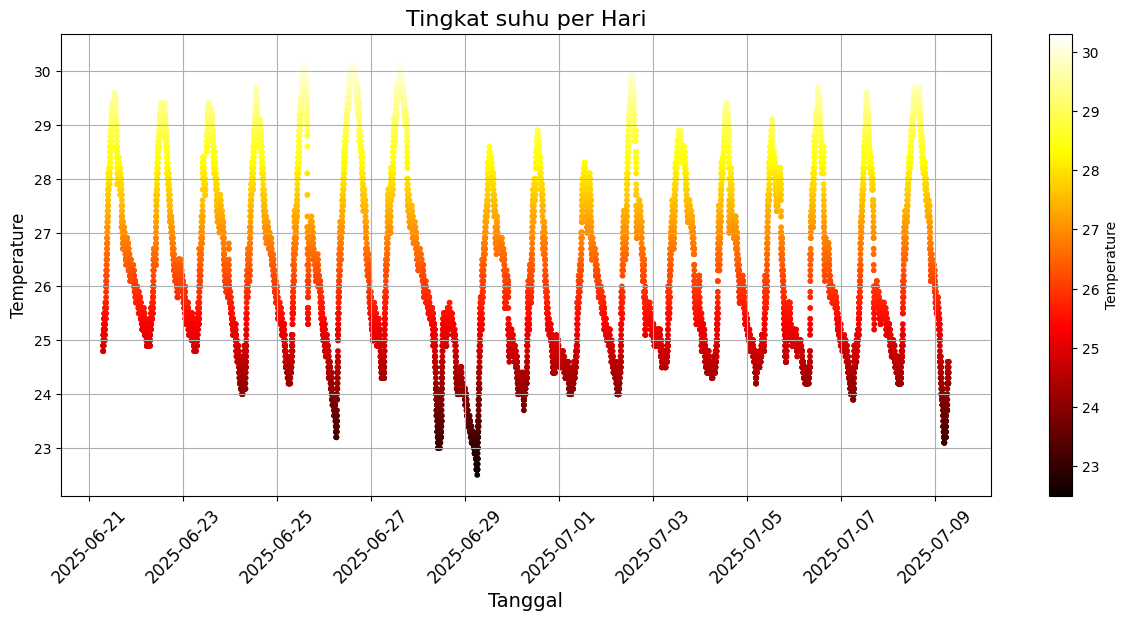

In [11]:
plt.figure(figsize=(15,6))
plt.scatter(df.index, df['Temperature'], c=df['Temperature'], cmap='hot', s=10)
plt.title('Tingkat suhu per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Temperature', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.colorbar(label='Temperature')
plt.grid(True)

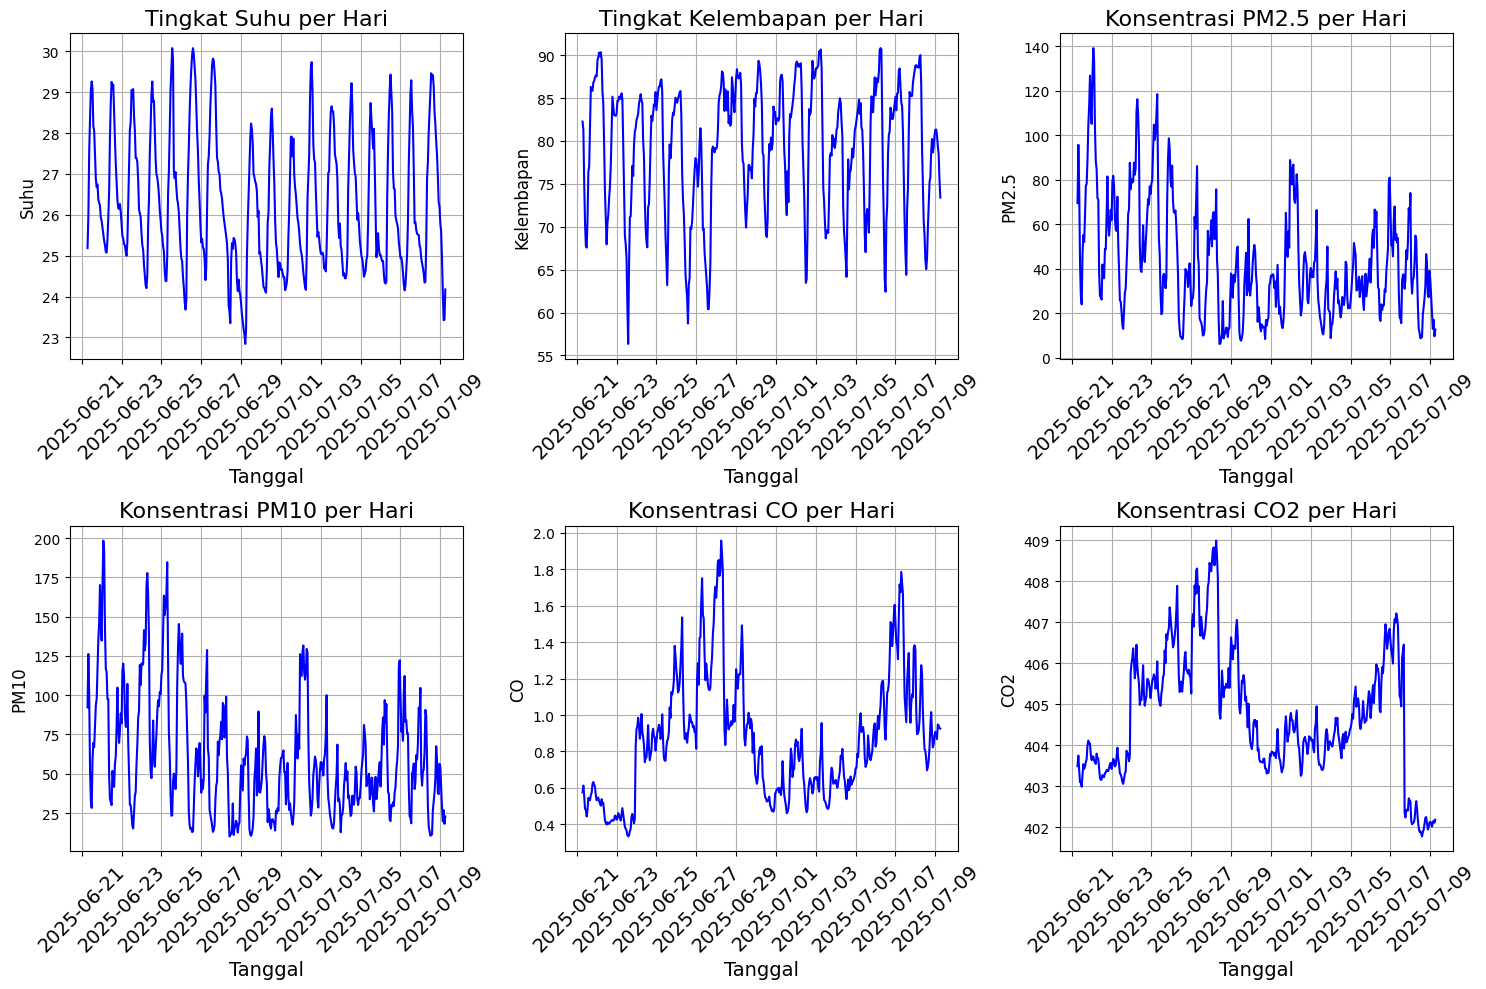

In [12]:
plt.figure(figsize=(15, 10))
plt.subplot(231)
sns.lineplot(data=df_resampled, x='created_at', y='Temperature', color='blue', markers='o')
plt.title('Tingkat Suhu per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Suhu', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(232)
sns.lineplot(data=df_resampled, x='created_at', y='Humidity', color='blue', markers='o')
plt.title('Tingkat Kelembapan per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Kelembapan', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(233)
sns.lineplot(data=df_resampled, x='created_at', y='PM2.5', color='blue', markers='o')
plt.title('Konsentrasi PM2.5 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('PM2.5', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(234)
sns.lineplot(data=df_resampled, x='created_at', y='PM10', color='blue', markers='o')
plt.title('Konsentrasi PM10 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('PM10', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(235)
sns.lineplot(data=df_resampled, x='created_at', y='CO', color='blue', markers='o')
plt.title('Konsentrasi CO per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('CO', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(236)
sns.lineplot(data=df_resampled, x='created_at', y='CO2', color='blue', markers='o')
plt.title('Konsentrasi CO2 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('CO2', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.tight_layout()
plt.show()

## **Data Splitting dan Window**

In [13]:
# 1. Split Data
# Tentukan proporsi
n = len(df_resampled)
train_size = int(n * 0.7)
val_size = int(n * 0.15)

# Split berdasarkan urutan waktu
train_df = df_resampled.iloc[:train_size]
val_df   = df_resampled.iloc[train_size:train_size + val_size]
test_df  = df_resampled.iloc[train_size + val_size:]

In [11]:
# # 2. Normalization layer
# train_array = train_df.values
# val_array   = val_df.values
# test_array  = test_df.values

# normalizer = tf.keras.layers.Normalization(axis=-1)
# normalizer.adapt(train_array)

In [12]:
# print("normalizer.mean shape:", normalizer.mean.shape)
# print("target_cols:", target_cols)

**Scaling**

In [14]:
def scale_dataset_per_feature(df):
    scalers = []
    scaled_data = []

    for col in df.columns:
        scaler = StandardScaler()
        scaled_col = scaler.fit_transform(df[[col]])  # tetap bentuk 2D
        scaled_data.append(scaled_col)
        scalers.append(scaler)

    scaled_array = np.hstack(scaled_data)
    return scaled_array, scalers

train_scaled, scalers = scale_dataset_per_feature(train_df)
val_scaled = np.hstack([scalers[i].transform(val_df[[col]]) for i, col in enumerate(val_df.columns)])
test_scaled = np.hstack([scalers[i].transform(test_df[[col]]) for i, col in enumerate(test_df.columns)])


**Window**

In [14]:
tf.random.set_seed(42)

# Membuat fungsi untuk split data input dan target
def split_inputs_and_targets(mulvar_series, ahead=60, target_cols=[2, 3, 4, 5]):
    # input semua timestamp kecuali 10 langkah ke depan
    X = mulvar_series[:, :-ahead, :]

    # output: nilai aktual untuk 60 langkah kedepan
    Y = mulvar_series[:, -ahead:, :]
    Y = tf.gather(Y, target_cols, axis=-1) 
    
    return X, Y

In [15]:
# === Konfigurasi
seq_length = 60   # input 60 menit ke belakang
ahead = 60        # prediksi 60 menit ke depan
target_cols = [2, 3, 4, 5]  # PM2.5, PM10, CO, CO2

# === Dataset Training
ahead_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets)

# === Dataset Validasi
ahead_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=val_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets)

# === Dataset Testing (jangan di-shuffle)
ahead_test_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
).map(split_inputs_and_targets)

In [16]:
import os

# Create a function to implement a ModelCheckpoint callback with a specific filename 
def create_model_checkpoint(model_name, save_path="model_experiments"):
  return tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(save_path, model_name), # create filepath to save model
    verbose=0, # only output a limited amount of text
    save_best_only=True) # save only the best model to file

## **Model Experiment**

### Model 1: LSTM(4 layer) (Window = 60, horizon = 60)

In [17]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True, input_shape=(60, 6)),  # 60 timesteps, 6 fitur
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(256, return_sequences=True),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(60 * 4),                 # 60 langkah output * 4 fitur
    tf.keras.layers.Reshape((60, 4))               # Kembalikan ke shape: (60, 4)
], name="Model_1_LSTM")

In [18]:
optimizer = tf.keras.optimizers.Adam()
model_1.compile(loss="mae", optimizer=optimizer, metrics=["mae"])

In [19]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_mae', patience=10, restore_best_weights=True)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_model_lstm_trial.h5", save_best_only=True, monitor="val_mae")

In [20]:
model_1.summary()

Model: "Model_1_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 128)           69120     
                                                                 
 lstm_1 (LSTM)               (None, 60, 128)           131584    
                                                                 
 lstm_2 (LSTM)               (None, 60, 256)           394240    
                                                                 
 lstm_3 (LSTM)               (None, 128)               197120    
                                                                 
 dense (Dense)               (None, 240)               30960     
                                                                 
 reshape (Reshape)           (None, 60, 4)             0         
                                                                 
Total params: 823,024
Trainable params: 823,024
Non-tr

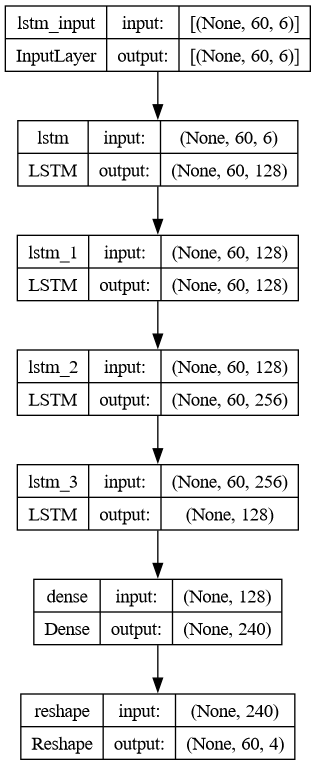

In [21]:
tf.keras.utils.plot_model(model_1, show_shapes=True)

In [22]:
with tf.device('/GPU:0'):
    history = model_1.fit(ahead_train_ds, epochs=50, validation_data=ahead_valid_ds, callbacks=[create_model_checkpoint(model_name=model_1.name), early_stopping_cb])

Epoch 1/50
564/564 [==============================] - ETA: 0s - loss: 0.0434 - mae: 0.0434

INFO:tensorflow:Assets written to: model_experiments\Model_1_LSTM\assets


INFO:tensorflow:Assets written to: model_experiments\Model_1_LSTM\assets


564/564 [==============================] - 33s 44ms/step - loss: 0.0434 - mae: 0.0434 - val_loss: 0.0307 - val_mae: 0.0307
Epoch 2/50
562/564 [============================>.] - ETA: 0s - loss: 0.0353 - mae: 0.0353

INFO:tensorflow:Assets written to: model_experiments\Model_1_LSTM\assets


...

INFO:tensorflow:Assets written to: model_experiments\Model_1_LSTM\assets


564/564 [==============================] - 23s 40ms/step - loss: 0.0325 - mae: 0.0325 - val_loss: 0.0269 - val_mae: 0.0269
Epoch 5/50
563/564 [============================>.] - ETA: 0s - loss: 0.0319 - mae: 0.0319

INFO:tensorflow:Assets written to: model_experiments\Model_1_LSTM\assets


INFO:tensorflow:Assets written to: model_experiments\Model_1_LSTM\assets


564/564 [==============================] - 44s 79ms/step - loss: 0.0319 - mae: 0.0319 - val_loss: 0.0266 - val_mae: 0.0266
Epoch 6/50
564/564 [==============================] - 15s 26ms/step - loss: 0.0313 - mae: 0.0313 - val_loss: 0.0280 - val_mae: 0.0280
Epoch 7/50
564/564 [==============================] - 14s 25ms/step - loss: 0.0306 - mae: 0.0306 - val_loss: 0.0271 - val_mae: 0.0271
Epoch 8/50
564/564 [==============================] - 14s 25ms/step - loss: 0.0300 - mae: 0.0300 - val_loss: 0.0280 - val_mae: 0.0280
Epoch 9/50
564/564 [==============================] - 14s 25ms/step - loss: 0.0293 - mae: 0.0293 - val_loss: 0.0281 - val_mae: 0.0281
Epoch 10/50
564/564 [==============================] - 14s 25ms/step - loss: 0.0287 - mae: 0.0287 - val_loss: 0.0287 - val_mae: 0.0287
Epoch 11/50
564/564 [==============================] - 14s 24ms/step - loss: 0.0276 - mae: 0.0276 - val_loss: 0.0367 - val_mae: 0.0367
Epoch 12/50
564/564 [==============================] - 14s 25ms/step - 

In [23]:
model_1.evaluate(ahead_test_ds)

118/118 [==============================] - 1s 10ms/step - loss: 0.0930 - mae: 0.0930


[0.09298371523618698, 0.0929836854338646]

In [24]:
# Load in saved best performing model_1 and evaluate on test data
model_1 = tf.keras.models.load_model("model_experiments/Model_1_LSTM")
model_1.evaluate(ahead_test_ds)

118/118 [==============================] - 2s 11ms/step - loss: 0.0930 - mae: 0.0930


[0.09298371523618698, 0.0929836854338646]

In [25]:
def inverse_scale_predictions(y_scaled, scalers, target_cols):
    """
    Inverse MinMaxScaler untuk data prediksi/aktual agar kembali ke skala asli.

    Parameters:
        y_scaled (ndarray): array prediksi/aktual shape (batch, timestep, target)
        scalers (list): list scaler yang sesuai dengan urutan df.columns
        target_cols (list): index kolom target, misal [2, 3, 4, 5]

    Returns:
        ndarray: data dalam skala asli, shape sama dengan y_scaled
    """
    y_inversed = np.empty_like(y_scaled)
    for i, col_idx in enumerate(target_cols):
        for j in range(y_scaled.shape[0]):
            y_inversed[j, :, i] = scalers[col_idx].inverse_transform(
                y_scaled[j, :, i].reshape(-1, 1)
            ).flatten()
    return y_inversed

In [26]:
def plot_prediction_from_batch(y_true_scaled, y_pred_scaled, scalers, target_cols, feature_names):
    """
    Visualisasi prediksi vs aktual dari batch pertama dataset.

    Parameters:
        y_true_scaled (ndarray): output aktual hasil dari dataset, shape (batch, timestep, target)
        y_pred_scaled (ndarray): output prediksi dari model, shape (batch, timestep, target)
        scalers (list): list of MinMaxScaler
        target_cols (list): indeks kolom target (misal: [2,3,4,5])
        feature_names (list): nama-nama fitur target (misal: ["PM2.5", "PM10", "CO", "CO2"])
    """
    # Inverse dulu
    y_true_inv = inverse_scale_predictions(y_true_scaled, scalers, target_cols)
    y_pred_inv = inverse_scale_predictions(y_pred_scaled, scalers, target_cols)

    for i in range(len(target_cols)):
        plt.figure(figsize=(10, 4))
        plt.plot(y_true_inv[0, :, i], label=f"Aktual {feature_names[i]}")
        plt.plot(y_pred_inv[0, :, i], label=f"Prediksi {feature_names[i]}")
        plt.title(f'Prediksi vs Aktual - {feature_names[i]} (1 batch)')
        plt.xlabel('Menit ke-')
        plt.ylabel(feature_names[i])
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

1/1 [==============================] - 1s 807ms/step


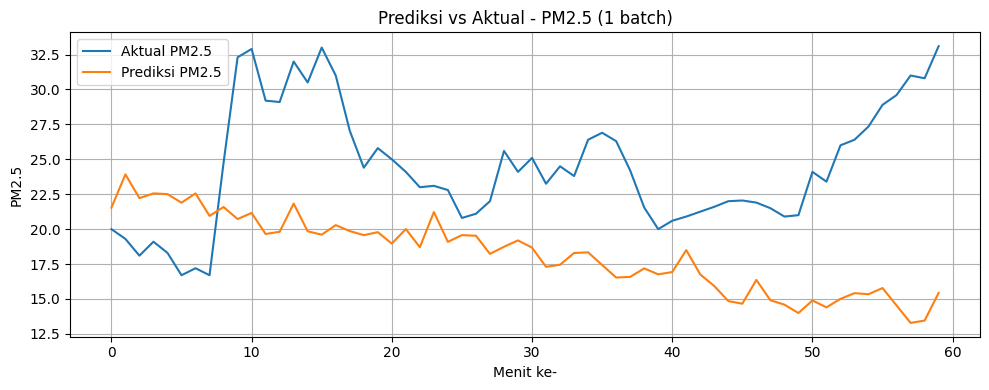

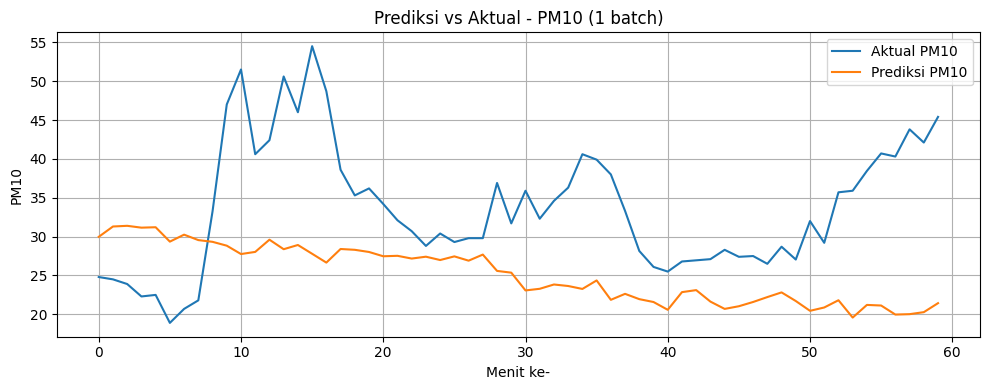

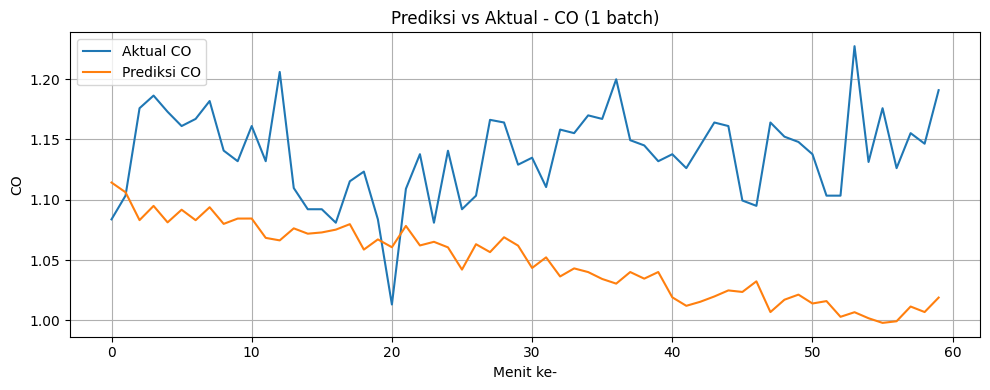

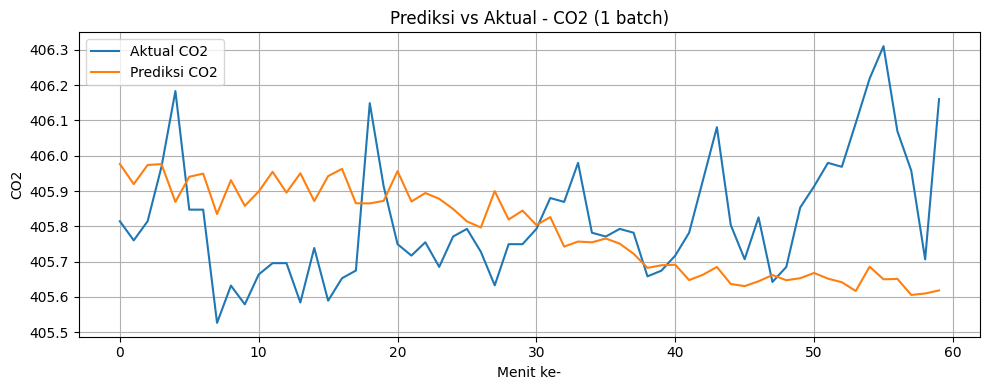

In [27]:
for x_batch, y_true_batch in ahead_test_ds.take(1):
    y_pred_batch = model_1.predict(x_batch)
    y_true_batch = y_true_batch.numpy()

    plot_prediction_from_batch(
        y_true_scaled=y_true_batch,
        y_pred_scaled=y_pred_batch,
        scalers=scalers,
        target_cols=[2, 3, 4, 5],
        feature_names=["PM2.5", "PM10", "CO", "CO2"]
    )

In [28]:
def make_preds_multistep(model, dataset):
    """
    Mengambil prediksi dan ground truth dari dataset windowed.
    Output shape: (batch, 60, 4)
    """
    y_preds = []
    y_trues = []

    for x_batch, y_batch in dataset:
        y_pred_batch = model.predict(x_batch)
        y_preds.append(y_pred_batch)
        y_trues.append(y_batch.numpy())

    y_preds = np.concatenate(y_preds, axis=0)
    y_trues = np.concatenate(y_trues, axis=0)

    return y_trues, y_preds

In [29]:
def evaluate_preds_multistep(y_true, y_pred, scalers, target_cols, feature_names):
    """
    Evaluasi MAE, MSE, RMSE, MAPE per fitur target.
    Scaling dibalik menggunakan MinMaxScaler (bukan normalizer).
    """
    # Inverse ke skala asli
    y_true_inv = inverse_scale_predictions(y_true, scalers, target_cols)
    y_pred_inv = inverse_scale_predictions(y_pred, scalers, target_cols)

    results = {}
    for i, name in enumerate(feature_names):
        mae  = tf.keras.metrics.mean_absolute_error(y_true_inv[:, :, i], y_pred_inv[:, :, i])
        mse  = tf.keras.metrics.mean_squared_error(y_true_inv[:, :, i], y_pred_inv[:, :, i])
        rmse = tf.sqrt(mse)
        mape = tf.keras.metrics.mean_absolute_percentage_error(y_true_inv[:, :, i], y_pred_inv[:, :, i])

        results[name] = {
            "MAE":  float(tf.reduce_mean(mae).numpy()),
            "MSE":  float(tf.reduce_mean(mse).numpy()),
            "RMSE": float(tf.reduce_mean(rmse).numpy()),
            "MAPE": float(tf.reduce_mean(mape).numpy())
        }

    return results


In [30]:
y_true_1, y_pred_1 = make_preds_multistep(model_1, ahead_test_ds)

results_1 = evaluate_preds_multistep(
    y_true=y_true_1,
    y_pred=y_pred_1,
    scalers=scalers,
    target_cols=[2, 3, 4, 5],
    feature_names=["PM2.5", "PM10", "CO", "CO2"]
)


1/1 [==============================] - 1s 797ms/step


In [31]:
results_1

{'PM2.5': {'MAE': 17.75136375427246,
  'MSE': 546.3585205078125,
  'RMSE': 20.831052780151367,
  'MAPE': 57.18997573852539},
 'PM10': {'MAE': 27.027889251708984,
  'MSE': 1252.6712646484375,
  'RMSE': 31.571243286132812,
  'MAPE': 61.896541595458984},
 'CO': {'MAE': 0.319987028837204,
  'MSE': 0.1561736762523651,
  'RMSE': 0.33778858184814453,
  'MAPE': 30.19199562072754},
 'CO2': {'MAE': 0.43429598212242126,
  'MSE': 0.4142635762691498,
  'RMSE': 0.5055128335952759,
  'MAPE': 0.10755215585231781}}

### Model 2: LSTM(3 layer), Dense, Dropout, (Window = 60, horizon = 60)

In [32]:
model_2 = tf.keras.Sequential([
    tf.keras.Input(shape=(60, 6)),  # 60 timestep, 6 fitur
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(256, return_sequences=True),
    tf.keras.layers.Dropout(0.2),                             
    # Regularisasi agar tidak overfit
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(256, activation='relu'),            
    # Tambahan Dense layer sebelum output
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(60 * 4),                            
    # output untuk 60 timestep × 4 target
    tf.keras.layers.Reshape((60, 4))                          
    # ubah bentuk ke time series output
], name="Model_2_LSTM_Dropout")

model_2.compile(optimizer='adam', loss='mae', metrics=['mae'])

In [33]:
with tf.device('/GPU:0'):
    history_2 = model_2.fit(
        ahead_train_ds,
        validation_data=ahead_valid_ds,
        epochs=100,
        callbacks=[
            create_model_checkpoint("Model_2_LSTM_Dropout"),
            early_stopping_cb
        ]
    )

Epoch 1/100
562/564 [============================>.] - ETA: 0s - loss: 0.0473 - mae: 0.0473

INFO:tensorflow:Assets written to: model_experiments\Model_2_LSTM_Dropout\assets


INFO:tensorflow:Assets written to: model_experiments\Model_2_LSTM_Dropout\assets


564/564 [==============================] - 22s 34ms/step - loss: 0.0472 - mae: 0.0472 - val_loss: 0.0278 - val_mae: 0.0278
Epoch 2/100
564/564 [==============================] - 12s 21ms/step - loss: 0.0372 - mae: 0.0372 - val_loss: 0.0291 - val_mae: 0.0291
Epoch 3/100
564/564 [==============================] - 10s 18ms/step - loss: 0.0354 - mae: 0.0354 - val_loss: 0.0287 - val_mae: 0.0287
Epoch 4/100
564/564 [==============================] - 10s 18ms/step - loss: 0.0349 - mae: 0.0349 - val_loss: 0.0297 - val_mae: 0.0297
Epoch 5/100
564/564 [==============================] - 10s 18ms/step - loss: 0.0343 - mae: 0.0343 - val_loss: 0.0281 - val_mae: 0.0281
Epoch 6/100
564/564 [==============================] - 11s 19ms/step - loss: 0.0337 - mae: 0.0337 - val_loss: 0.0279 - val_mae: 0.0279
Epoch 7/100
562/564 [============================>.] - ETA: 0s - loss: 0.0332 - mae: 0.0332

INFO:tensorflow:Assets written to: model_experiments\Model_2_LSTM_Dropout\assets


INFO:tensorflow:Assets written to: model_experiments\Model_2_LSTM_Dropout\assets


564/564 [==============================] - 15s 27ms/step - loss: 0.0332 - mae: 0.0332 - val_loss: 0.0276 - val_mae: 0.0276
Epoch 8/100
564/564 [==============================] - 10s 18ms/step - loss: 0.0330 - mae: 0.0330 - val_loss: 0.0286 - val_mae: 0.0286
Epoch 9/100
564/564 [==============================] - 10s 17ms/step - loss: 0.0328 - mae: 0.0328 - val_loss: 0.0280 - val_mae: 0.0280
Epoch 10/100
563/564 [============================>.] - ETA: 0s - loss: 0.0323 - mae: 0.0323

INFO:tensorflow:Assets written to: model_experiments\Model_2_LSTM_Dropout\assets


INFO:tensorflow:Assets written to: model_experiments\Model_2_LSTM_Dropout\assets


564/564 [==============================] - 17s 30ms/step - loss: 0.0323 - mae: 0.0323 - val_loss: 0.0269 - val_mae: 0.0269
Epoch 11/100
564/564 [==============================] - 11s 20ms/step - loss: 0.0321 - mae: 0.0321 - val_loss: 0.0295 - val_mae: 0.0295
Epoch 12/100
564/564 [==============================] - 11s 20ms/step - loss: 0.0316 - mae: 0.0316 - val_loss: 0.0284 - val_mae: 0.0284
Epoch 13/100
564/564 [==============================] - 11s 20ms/step - loss: 0.0313 - mae: 0.0313 - val_loss: 0.0293 - val_mae: 0.0293
Epoch 14/100
564/564 [==============================] - 11s 19ms/step - loss: 0.0310 - mae: 0.0310 - val_loss: 0.0277 - val_mae: 0.0277
Epoch 15/100
564/564 [==============================] - 11s 20ms/step - loss: 0.0307 - mae: 0.0307 - val_loss: 0.0304 - val_mae: 0.0304
Epoch 16/100
564/564 [==============================] - 11s 20ms/step - loss: 0.0303 - mae: 0.0303 - val_loss: 0.0288 - val_mae: 0.0288
Epoch 17/100
564/564 [==============================] - 11s 2

In [34]:
model_2.evaluate(ahead_test_ds)

118/118 [==============================] - 1s 8ms/step - loss: 0.1090 - mae: 0.1090


[0.10895317047834396, 0.10895316302776337]

In [35]:
# Load in saved best performing model_1 and evaluate on test data
model_2 = tf.keras.models.load_model("model_experiments/Model_2_LSTM_Dropout")
model_2.evaluate(ahead_test_ds)

118/118 [==============================] - 2s 10ms/step - loss: 0.1090 - mae: 0.1090


[0.10895317047834396, 0.10895316302776337]

In [36]:
y_true_2, y_pred_2 = make_preds_multistep(model_2, ahead_test_ds)

results_2 = evaluate_preds_multistep(
    y_true=y_true_2,
    y_pred=y_pred_2,
    scalers=scalers,
    target_cols=[2, 3, 4, 5],
    feature_names=["PM2.5", "PM10", "CO", "CO2"]
)

1/1 [==============================] - 1s 624ms/step


1/1 [==============================] - 0s 23ms/step


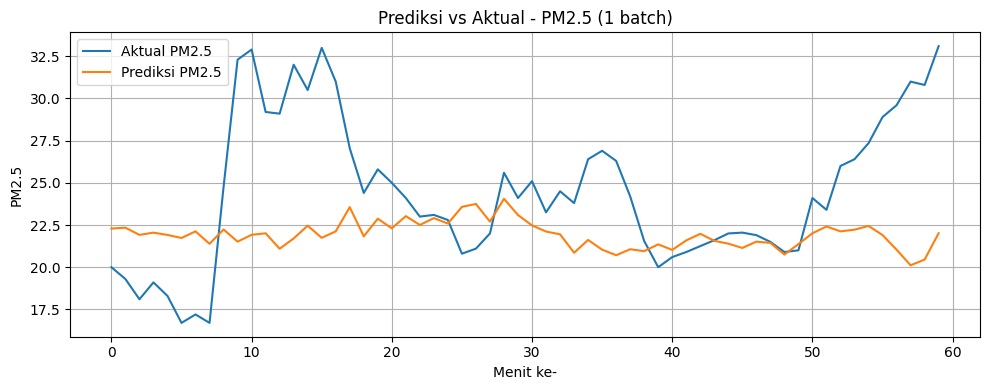

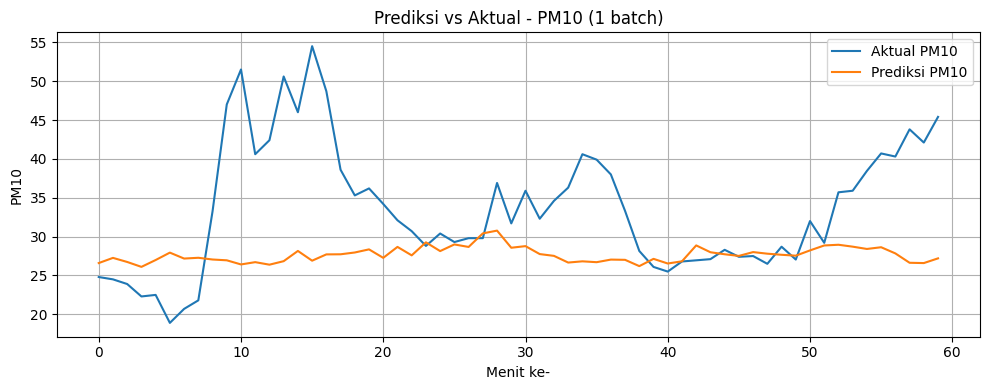

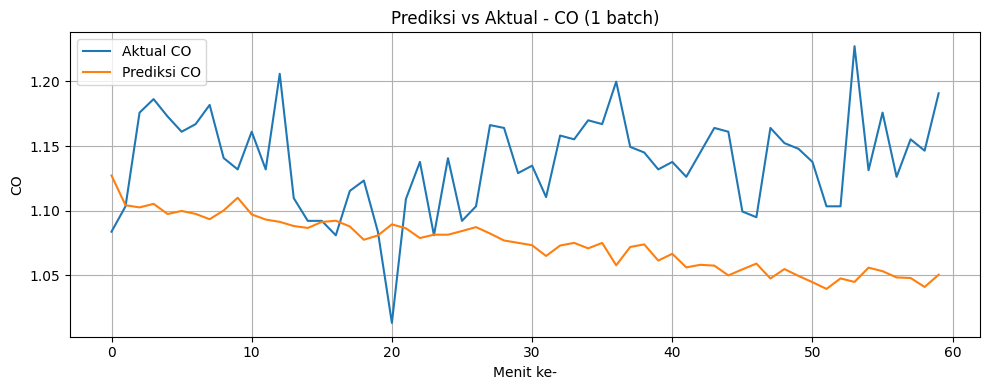

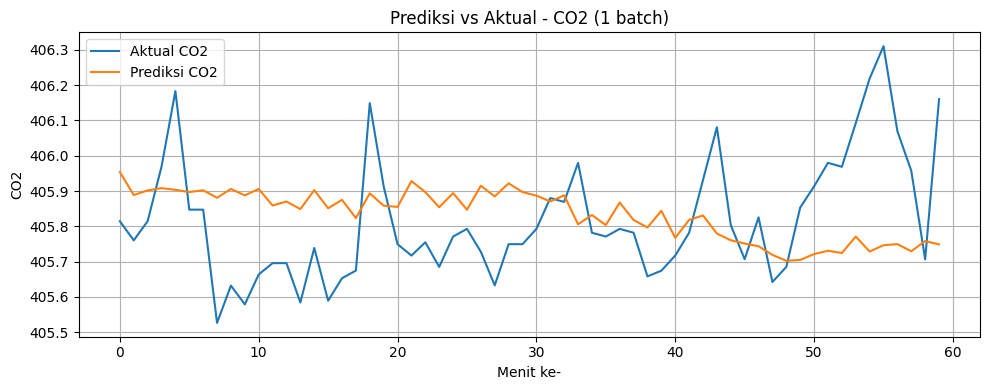

In [37]:
for x_batch, y_true_batch in ahead_test_ds.take(1):
    y_pred_batch = model_2.predict(x_batch)
    y_true_batch = y_true_batch.numpy()

    plot_prediction_from_batch(
        y_true_scaled=y_true_batch,
        y_pred_scaled=y_pred_batch,
        scalers=scalers,
        target_cols=[2, 3, 4, 5],
        feature_names=["PM2.5", "PM10", "CO", "CO2"]
    )

In [38]:
results_2

{'PM2.5': {'MAE': 24.386201858520508,
  'MSE': 863.8983764648438,
  'RMSE': 26.053802490234375,
  'MAPE': 107.86869812011719},
 'PM10': {'MAE': 33.98394775390625,
  'MSE': 1671.2337646484375,
  'RMSE': 36.50929641723633,
  'MAPE': 106.51593780517578},
 'CO': {'MAE': 0.28782564401626587,
  'MSE': 0.13319702446460724,
  'RMSE': 0.32686054706573486,
  'MAPE': 26.535951614379883},
 'CO2': {'MAE': 0.6609033942222595,
  'MSE': 0.7658044099807739,
  'RMSE': 0.783545732498169,
  'MAPE': 0.16375519335269928}}

### Model 3: Sequence to Vector with Autoregressive

In [48]:
from sklearn.preprocessing import RobustScaler

def scale_dataset_per_feature_robust(df):
    Rscalers = []
    scaled_data = []

    for col in df.columns:
        Rscaler = RobustScaler()
        scaled_col = Rscaler.fit_transform(df[[col]])  # tetap bentuk 2D
        scaled_data.append(scaled_col)
        scalers.append(Rscaler)

    scaled_array = np.hstack(scaled_data)
    return scaled_array, scalers

train_scaled, scalers = scale_dataset_per_feature_robust(train_df)
val_scaled = np.hstack([scalers[i].transform(val_df[[col]]) for i, col in enumerate(val_df.columns)])
test_scaled = np.hstack([scalers[i].transform(test_df[[col]]) for i, col in enumerate(test_df.columns)])


In [49]:
def split_seq2vec(mulvar_series, ahead=1, target_cols=[2, 3, 4, 5]):
    """
    Membuat input-output untuk seq-to-vector:
    - Input: (batch, 60, fitur)
    - Output: (batch, 1, target)
    """
    X = mulvar_series[:, :-ahead, :]  # ambil 60 langkah ke belakang
    Y = mulvar_series[:, -ahead:, :]  # ambil langkah ke-61
    Y = tf.gather(Y, target_cols, axis=-1)  # ambil hanya target yang diinginkan

    return X, Y

In [50]:
seq_length = 60
ahead = 1
target_cols = [2, 3, 4, 5]  # PM2.5, PM10, CO, CO2

# Training set
vec_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(lambda window: split_seq2vec(window, ahead, target_cols))

# Validation set
vec_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=val_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(lambda window: split_seq2vec(window, ahead, target_cols))

# Test set
vec_test_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
).map(lambda window: split_seq2vec(window, ahead, target_cols))


In [51]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model_3 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(60, 6)),               # 60 timestep, 6 fitur
    tf.keras.layers.LSTM(128, return_sequences=True),  # Output 1 vector
    tf.keras.layers.LSTM(128),  # Output 1 vector
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(4)                            # 4 target
], name="Model_3")

In [52]:
model_3.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mae']
)

In [53]:
with tf.device('/GPU:0'):
    history_3 = model_3.fit(
        vec_train_ds,
        epochs=100,
        validation_data=vec_valid_ds,
        callbacks=[create_model_checkpoint("Model_3"), early_stopping_cb]
    )

Epoch 1/100
563/566 [============================>.] - ETA: 0s - loss: 0.5752 - mae: 0.5752

INFO:tensorflow:Assets written to: model_experiments\Model_3\assets


INFO:tensorflow:Assets written to: model_experiments\Model_3\assets


566/566 [==============================] - 16s 24ms/step - loss: 0.5753 - mae: 0.5753 - val_loss: 0.4689 - val_mae: 0.4689
Epoch 2/100
566/566 [==============================] - 8s 14ms/step - loss: 0.5750 - mae: 0.5749 - val_loss: 0.4730 - val_mae: 0.4732
Epoch 3/100
566/566 [==============================] - 8s 14ms/step - loss: 0.5749 - mae: 0.5748 - val_loss: 0.4804 - val_mae: 0.4805
Epoch 4/100
566/566 [==============================] - 8s 14ms/step - loss: 0.5748 - mae: 0.5748 - val_loss: 0.4771 - val_mae: 0.4771
Epoch 5/100
566/566 [==============================] - 9s 17ms/step - loss: 0.5748 - mae: 0.5748 - val_loss: 0.4797 - val_mae: 0.4799
Epoch 6/100
566/566 [==============================] - 8s 15ms/step - loss: 0.5748 - mae: 0.5748 - val_loss: 0.4761 - val_mae: 0.4760
Epoch 7/100
566/566 [==============================] - 8s 14ms/step - loss: 0.5748 - mae: 0.5748 - val_loss: 0.4771 - val_mae: 0.4770
Epoch 8/100
566/566 [==============================] - 8s 14ms/step - los

In [55]:
def autoregressive_forecast(model, initial_input, steps, scalers, target_cols):
    """
    Melakukan prediksi autoregressive sebanyak `steps` ke depan.
    
    Params:
        model        : Model seq-to-vector.
        initial_input: Array shape (1, 60, 6), input awal.
        steps        : Jumlah langkah ke depan.
        scalers      : List of fitted scalers per fitur.
        target_cols  : Index kolom target (PM2.5, PM10, CO, CO2).
    
    Returns:
        List of prediksi shape (steps, 4) - dalam skala asli.
    """
    input_seq = initial_input.copy()  # (1, 60, 6)
    preds = []

    for _ in range(steps):
        pred = model.predict(input_seq, verbose=0)  # (1, 4)
        preds.append(pred[0])  # Ambil dari batch pertama

        # Buat data baru dengan menggabungkan input lama + prediksi terbaru
        new_features = np.zeros((1, 1, input_seq.shape[2]))  # (1, 1, 6)
        for i, idx in enumerate(target_cols):
            new_features[0, 0, idx] = pred[0, i]
        
        # Sisipkan prediksi ke input_seq
        input_seq = np.concatenate([input_seq[:, 1:, :], new_features], axis=1)

    preds = np.array(preds)  # (steps, 4)

    # Inverse scaling
    preds_inv = preds.copy()
    for i, idx in enumerate(target_cols):
        preds_inv[:, i] = scalers[idx].inverse_transform(preds[:, i].reshape(-1, 1)).ravel()

    return preds_inv


In [57]:
# Ambil 1 input terakhir dari test set
input_for_forecast = test_scaled[-60:].reshape(1, 60, 6)

# Prediksi 60 menit ke depan
preds_inv = autoregressive_forecast(
    model=model_3,
    initial_input=input_for_forecast,
    steps=60,
    scalers=scalers,
    target_cols=[2, 3, 4, 5]
)


In [58]:
def plot_autoregressive_preds(preds_inv, df_actual, target_cols, feature_names):
    """
    Visualisasi prediksi autoregressive vs data aktual.
    
    preds_inv   : Array (60, 4) hasil prediksi dalam skala asli.
    df_actual   : DataFrame dengan index datetime dan kolom lengkap.
    target_cols : Index kolom target.
    feature_names: Nama target ['PM2.5', dst.]
    """
    # Ambil data aktual 60 menit ke depan dari waktu terakhir train/test
    actual_values = df_actual.iloc[-60:][[df_actual.columns[i] for i in target_cols]].values

    for i, name in enumerate(feature_names):
        plt.figure(figsize=(10, 4))
        plt.plot(actual_values[:, i], label=f"Aktual {name}")
        plt.plot(preds_inv[:, i], label=f"Prediksi {name}")
        plt.title(f"Prediksi 60 Menit ke Depan - {name}")
        plt.xlabel("Menit ke-")
        plt.ylabel(name)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


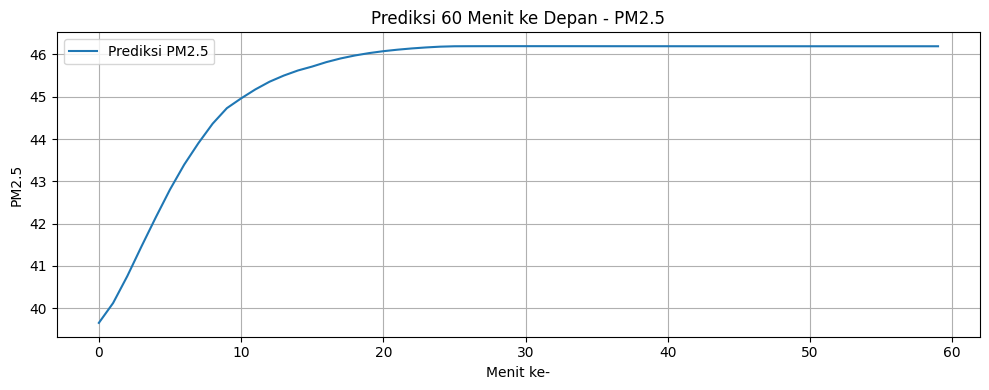

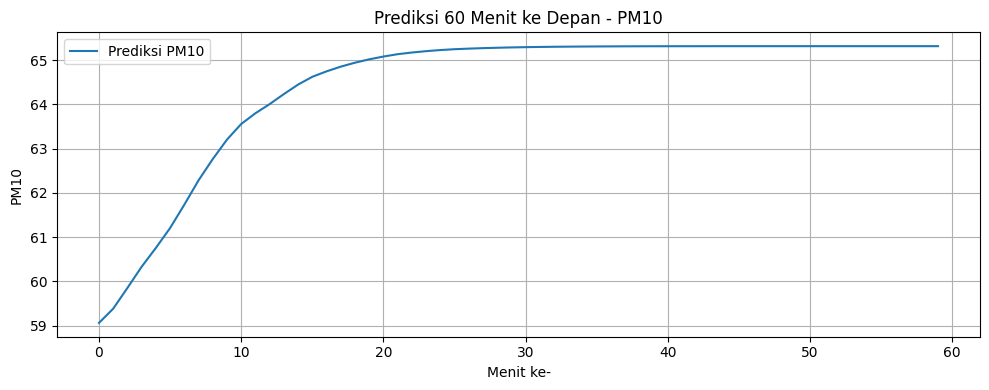

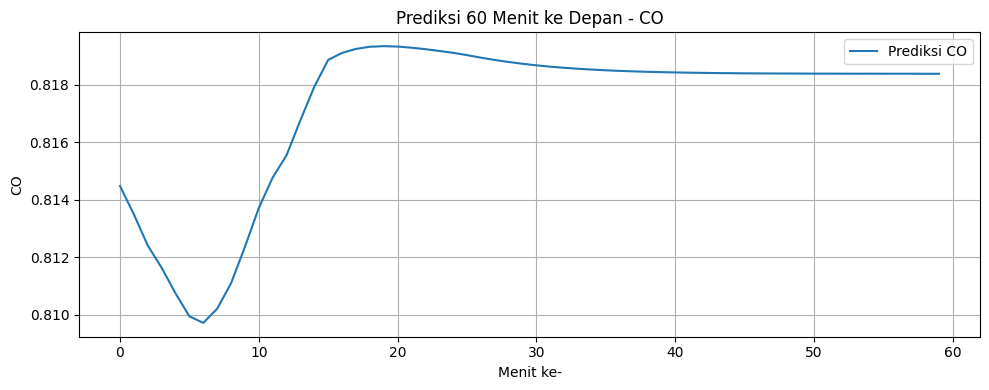

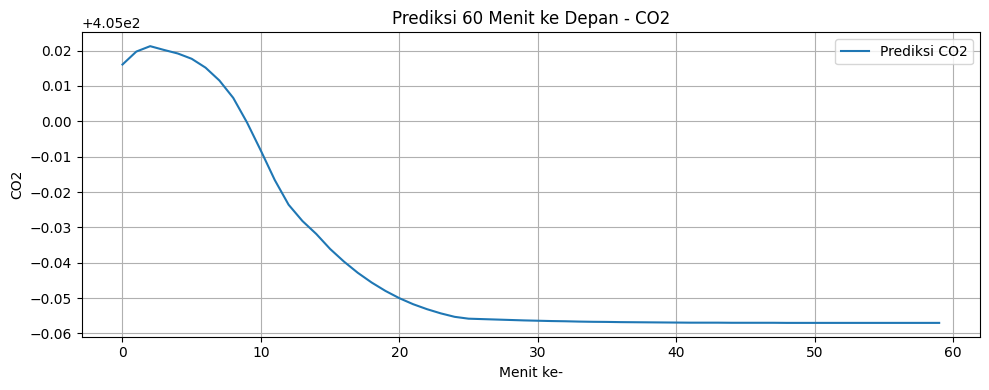

In [59]:

feature_names = ["PM2.5", "PM10", "CO", "CO2"]
for i in range(4):
    plt.figure(figsize=(10, 4))
    plt.plot(preds_inv[:, i], label=f"Prediksi {feature_names[i]}")
    plt.title(f"Prediksi 60 Menit ke Depan - {feature_names[i]}")
    plt.xlabel("Menit ke-")
    plt.ylabel(feature_names[i])
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

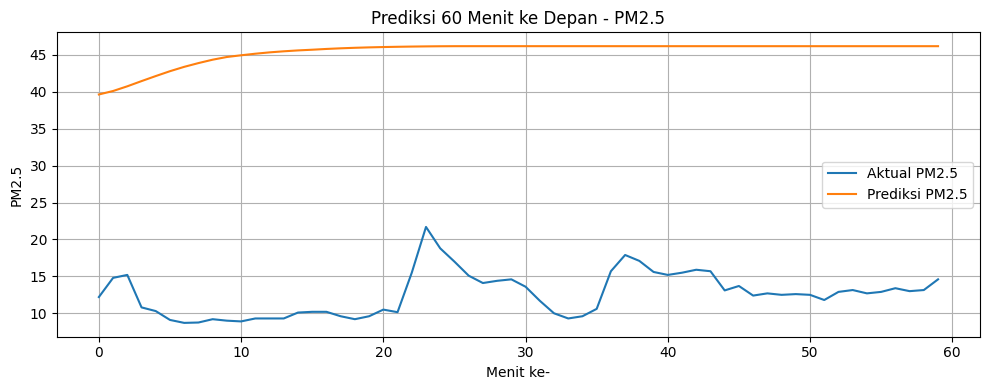

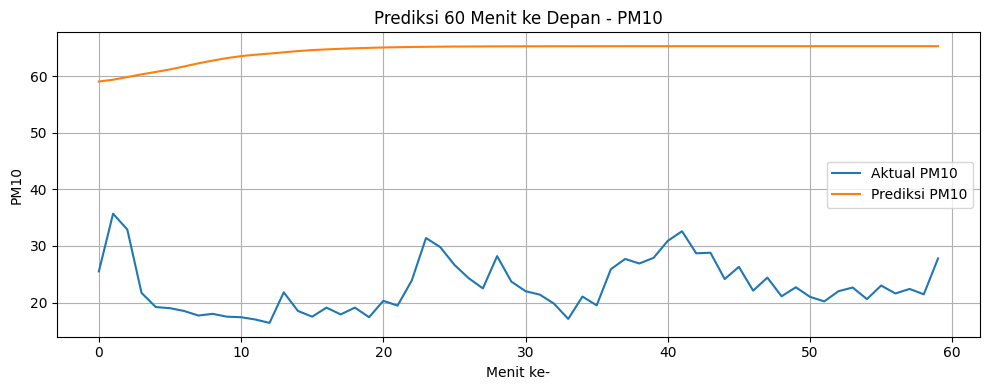

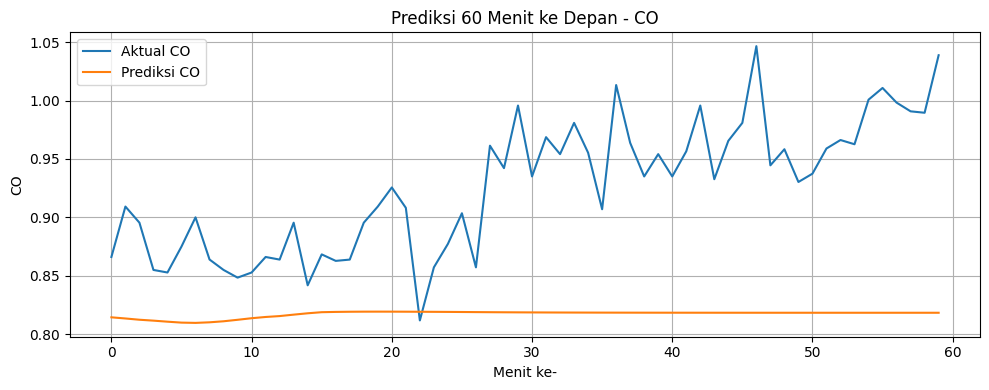

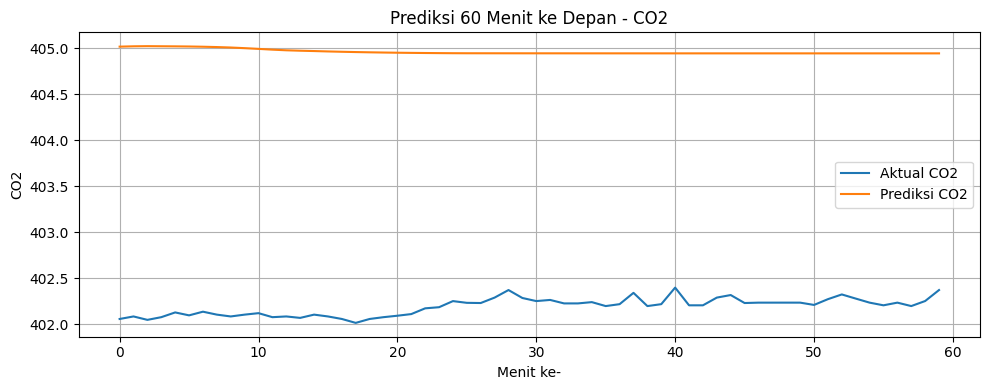

In [60]:
# Ambil 1 input terakhir dari test set
input_for_forecast = test_scaled[-60:].reshape(1, 60, 6)

# Prediksi 60 menit ke depan
preds_inv = autoregressive_forecast(
    model=model_3,
    initial_input=input_for_forecast,
    steps=60,
    scalers=scalers,
    target_cols=[2, 3, 4, 5]
)

# Plot hasilnya
plot_autoregressive_preds(
    preds_inv,
    df_actual=df_resampled,  # pastikan sudah di-resample dan sesuai waktu
    target_cols=[2, 3, 4, 5],
    feature_names=["PM2.5", "PM10", "CO", "CO2"]
)


<Axes: xlabel='PM2.5', ylabel='Count'>

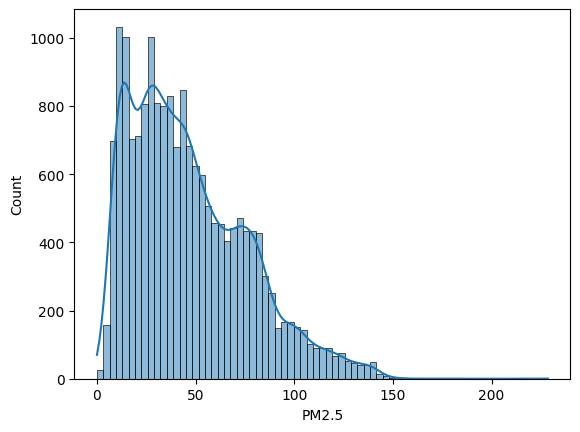

In [61]:
sns.histplot(train_df['PM2.5'], kde=True)

<Axes: ylabel='Count'>

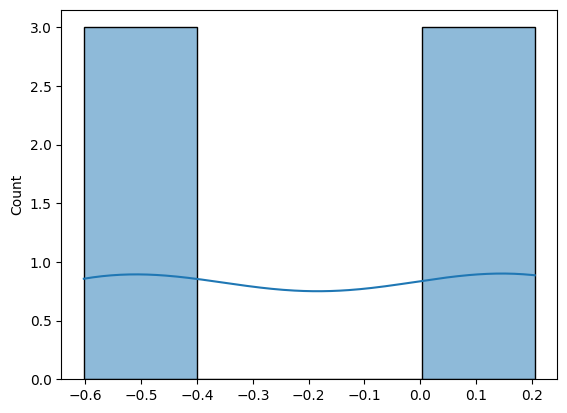

In [62]:
sns.histplot(train_scaled[2], kde=True)

### Model 4: LSTM + CNN

In [63]:
from sklearn.preprocessing import StandardScaler

def scale_dataset_per_feature_robust(df):
    scalers = []
    scaled_data = []

    for col in df.columns:
        scaler = RobustScaler()
        scaled_col = scaler.fit_transform(df[[col]])  # tetap bentuk 2D
        scaled_data.append(scaled_col)
        scalers.append(scaler)

    scaled_array = np.hstack(scaled_data)
    return scaled_array, scalers

train_scaled, scalers = scale_dataset_per_feature_robust(train_df)
val_scaled = np.hstack([scalers[i].transform(val_df[[col]]) for i, col in enumerate(val_df.columns)])
test_scaled = np.hstack([scalers[i].transform(test_df[[col]]) for i, col in enumerate(test_df.columns)])

In [64]:
tf.random.set_seed(42)

# Membuat fungsi untuk split data input dan target
def split_inputs_and_targets(mulvar_series, ahead=60, target_cols=[2, 3, 4, 5]):
    # input semua timestamp kecuali 10 langkah ke depan
    X = mulvar_series[:, :-ahead, :]

    # output: nilai aktual untuk 60 langkah kedepan
    Y = mulvar_series[:, -ahead:, :]
    Y = tf.gather(Y, target_cols, axis=-1) 
    
    return X, Y

In [65]:
# === Konfigurasi
seq_length = 60   # input 60 menit ke belakang
ahead = 60        # prediksi 60 menit ke depan
target_cols = [2, 3, 4, 5]  # PM2.5, PM10, CO, CO2

# === Dataset Training
ahead_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets)

# === Dataset Validasi
ahead_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=val_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets)

# === Dataset Testing (jangan di-shuffle)
ahead_test_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
).map(split_inputs_and_targets)

In [68]:
model_4 = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(60, 6)), # 60 timestep, 6 fitur
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(256, return_sequences=True),
    tf.keras.layers.Dropout(0.2),                             
    # Regularisasi agar tidak overfit
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(256, activation='relu'),            
    # Tambahan Dense layer sebelum output
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(60 * 4),                            
    # output untuk 60 timestep × 4 target
    tf.keras.layers.Reshape((60, 4))                          
    # ubah bentuk ke time series output
], name="Model_4_CNN_LSTM")

model_4.compile(optimizer='adam', loss='mae', metrics=['mae'])

In [69]:
with tf.device('/GPU:0'):
    history_4 = model_4.fit(
        ahead_train_ds,
        validation_data=ahead_valid_ds,
        epochs=100,
        callbacks=[
            create_model_checkpoint("Model_4_CNN_LSTM"),
            early_stopping_cb
        ]
    )

Epoch 1/100
564/564 [==============================] - ETA: 0s - loss: 0.1953 - mae: 0.1953

INFO:tensorflow:Assets written to: model_experiments\Model_4_CNN_LSTM\assets


INFO:tensorflow:Assets written to: model_experiments\Model_4_CNN_LSTM\assets


564/564 [==============================] - 24s 36ms/step - loss: 0.1953 - mae: 0.1953 - val_loss: 0.1422 - val_mae: 0.1422
Epoch 2/100
564/564 [==============================] - 12s 21ms/step - loss: 0.1611 - mae: 0.1611 - val_loss: 0.1470 - val_mae: 0.1470
Epoch 3/100
564/564 [==============================] - 12s 21ms/step - loss: 0.1518 - mae: 0.1518 - val_loss: 0.1610 - val_mae: 0.1610
Epoch 4/100
564/564 [==============================] - 12s 21ms/step - loss: 0.1455 - mae: 0.1455 - val_loss: 0.1922 - val_mae: 0.1922
Epoch 5/100
564/564 [==============================] - 12s 22ms/step - loss: 0.1379 - mae: 0.1379 - val_loss: 0.1979 - val_mae: 0.1979
Epoch 6/100
564/564 [==============================] - 12s 22ms/step - loss: 0.1335 - mae: 0.1335 - val_loss: 0.2059 - val_mae: 0.2059
Epoch 7/100
564/564 [==============================] - 12s 22ms/step - loss: 0.1275 - mae: 0.1275 - val_loss: 0.1915 - val_mae: 0.1915
Epoch 8/100
564/564 [==============================] - 13s 22ms/ste

In [73]:
# Load in saved best performing model_1 and evaluate on test data
model_4 = tf.keras.models.load_model("model_experiments/Model_4_CNN_LSTM")
model_4.evaluate(ahead_test_ds)

118/118 [==============================] - 2s 12ms/step - loss: 0.3972 - mae: 0.3972


[0.39715853333473206, 0.39715853333473206]

In [75]:
y_true_4, y_pred_4 = make_preds_multistep(model_4, ahead_test_ds)

results_4 = evaluate_preds_multistep(
    y_true=y_true_4,
    y_pred=y_pred_4,
    scalers=scalers,
    target_cols=[2, 3, 4, 5],
    feature_names=["PM2.5", "PM10", "CO", "CO2"]
)

1/1 [==============================] - 1s 625ms/step


1/1 [==============================] - 0s 24ms/step


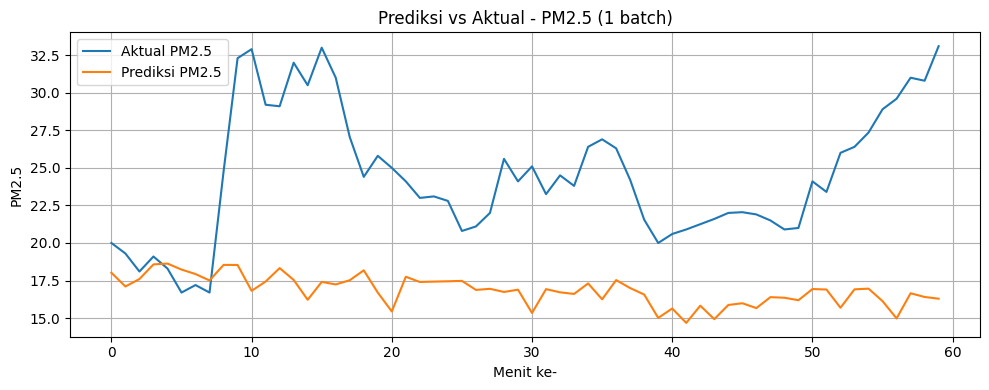

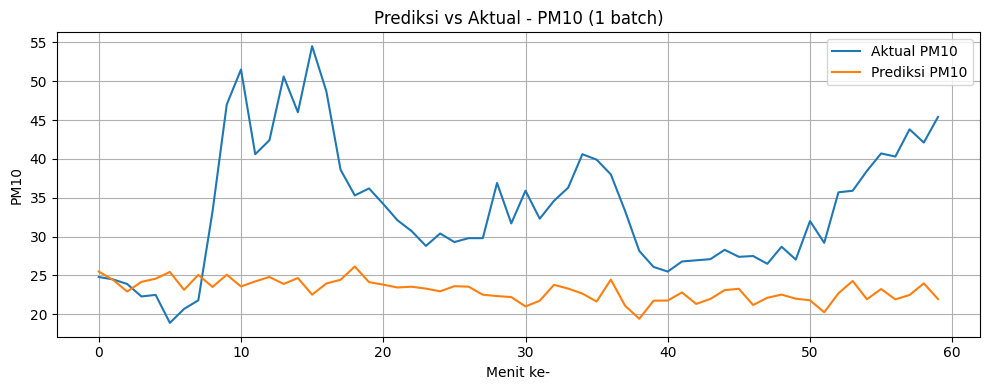

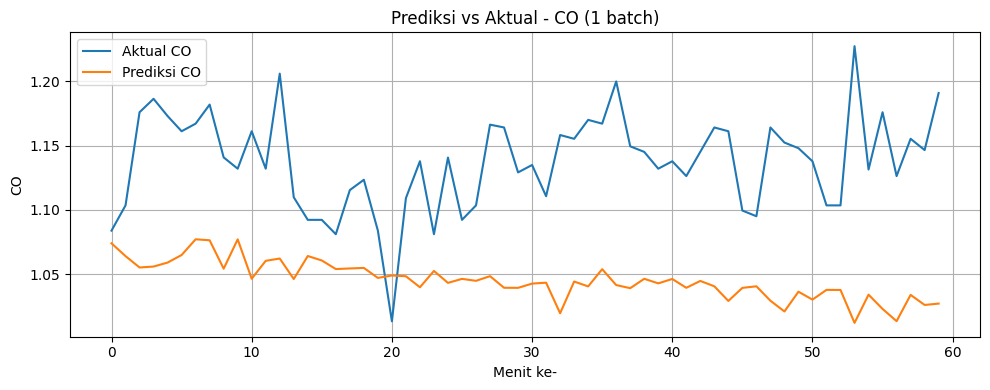

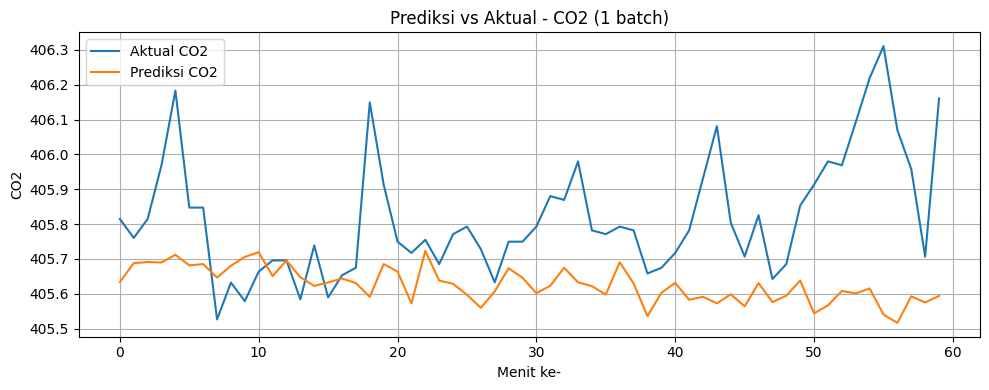

In [76]:
for x_batch, y_true_batch in ahead_test_ds.take(1):
    y_pred_batch = model_4.predict(x_batch)
    y_true_batch = y_true_batch.numpy()

    plot_prediction_from_batch(
        y_true_scaled=y_true_batch,
        y_pred_scaled=y_pred_batch,
        scalers=scalers,
        target_cols=[2, 3, 4, 5],
        feature_names=["PM2.5", "PM10", "CO", "CO2"]
    )

In [92]:
# === Konfigurasi
seq_length = 60   # input 60 menit ke belakang
ahead = 30        # prediksi 60 menit ke depan
target_cols = [2, 3, 4, 5]  # PM2.5, PM10, CO, CO2

# === Dataset Training
ahead_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets)

# === Dataset Validasi
ahead_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=val_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets)

# === Dataset Testing (jangan di-shuffle)
ahead_test_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
).map(split_inputs_and_targets)

In [93]:
# Model 5
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, LSTM, Dense, Dropout, Reshape

model_5 = Sequential([
    # --- Feature extraction dengan CNN
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='causal', input_shape=(60, 6)),
    BatchNormalization(),  # stabilisasi dan percepatan training

    # --- Sequence modeling dengan LSTM
    LSTM(64, return_sequences=True),
    LSTM(64, return_sequences=False),

    # --- Output projection
    Dense(128, activation='relu'),
    Dropout(0.1),  # tidak terlalu agresif

    Dense(60 * 4),        # output rata: 60 menit × 4 target
    Reshape((60, 4))      # output menjadi time series per fitur
], name="Model_CNN_LSTM_Optimized")

# Compile model
model_5.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [94]:
with tf.device('/GPU:0'):
    history_5 = model_5.fit(
        ahead_train_ds,
        validation_data=ahead_valid_ds,
        epochs=100,
        callbacks=[
            create_model_checkpoint("Model_CNN_LSTM_Optimized"),
            early_stopping_cb
        ]
    )

Epoch 1/100
562/565 [============================>.] - ETA: 0s - loss: 0.0880 - mae: 0.2072

INFO:tensorflow:Assets written to: model_experiments\Model_CNN_LSTM_Optimized\assets


INFO:tensorflow:Assets written to: model_experiments\Model_CNN_LSTM_Optimized\assets


565/565 [==============================] - 13s 19ms/step - loss: 0.0879 - mae: 0.2071 - val_loss: 0.0517 - val_mae: 0.1734
Epoch 2/100
565/565 [==============================] - 6s 11ms/step - loss: 0.0556 - mae: 0.1665 - val_loss: 0.0607 - val_mae: 0.1887
Epoch 3/100
565/565 [==============================] - 6s 11ms/step - loss: 0.0480 - mae: 0.1534 - val_loss: 0.0915 - val_mae: 0.2313
Epoch 4/100
565/565 [==============================] - 6s 10ms/step - loss: 0.0447 - mae: 0.1470 - val_loss: 0.0865 - val_mae: 0.2245
Epoch 5/100
565/565 [==============================] - 6s 10ms/step - loss: 0.0406 - mae: 0.1393 - val_loss: 0.0764 - val_mae: 0.2127
Epoch 6/100
565/565 [==============================] - 6s 10ms/step - loss: 0.0379 - mae: 0.1345 - val_loss: 0.0846 - val_mae: 0.2206
Epoch 7/100
565/565 [==============================] - 6s 10ms/step - loss: 0.0365 - mae: 0.1315 - val_loss: 0.0903 - val_mae: 0.2275
Epoch 8/100
565/565 [==============================] - 6s 10ms/step - los

In [95]:
# Load in saved best performing model_1 and evaluate on test data
model_5 = tf.keras.models.load_model("model_experiments/Model_CNN_LSTM_Optimized")
model_5.evaluate(ahead_test_ds)

119/119 [==============================] - 1s 7ms/step - loss: 0.3263 - mae: 0.4535


[0.3262656629085541, 0.4535179138183594]

In [96]:
y_true_5, y_pred_5 = make_preds_multistep(model_5, ahead_test_ds)

results_5 = evaluate_preds_multistep(
    y_true=y_true_5,
    y_pred=y_pred_5,
    scalers=scalers,
    target_cols=[2, 3, 4, 5],
    feature_names=["PM2.5", "PM10", "CO", "CO2"]
)

ValueError: in user code:

    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\engine\training.py", line 2041, in predict_function  *
        return step_function(self, iterator)
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\engine\training.py", line 2027, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\engine\training.py", line 2015, in run_step  **
        outputs = model.predict_step(data)
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\engine\training.py", line 1983, in predict_step
        return self(x, training=False)
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\l

In [97]:
for x_batch, y_true_batch in ahead_test_ds.take(1):
    y_pred_batch = model_5.predict(x_batch)
    y_true_batch = y_true_batch.numpy()

    plot_prediction_from_batch(
        y_true_scaled=y_true_batch,
        y_pred_scaled=y_pred_batch,
        scalers=scalers,
        target_cols=[2, 3, 4, 5],
        feature_names=["PM2.5", "PM10", "CO", "CO2"]
    )

ValueError: in user code:

    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\engine\training.py", line 2041, in predict_function  *
        return step_function(self, iterator)
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\engine\training.py", line 2027, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\engine\training.py", line 2015, in run_step  **
        outputs = model.predict_step(data)
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\engine\training.py", line 1983, in predict_step
        return self(x, training=False)
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\lib\site-packages\keras\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "c:\Users\Muhammad Mahdi\anaconda3\envs\main-ds\l

In [87]:
model_6 = Sequential([
    Input(shape=(60, 6)),

    # Feature extraction
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='causal'),
    BatchNormalization(),

    # Sequence modeling
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(128, return_sequences=False),
    Dropout(0.2),

    # Dense projection
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(60 * 4),          # 60 langkah ke depan × 4 target
    Reshape((60, 4))
], name="Model_6")

model_6.compile(optimizer='adam', loss='mae', metrics=['mae'])


In [88]:
with tf.device('/GPU:0'):
    history_6 = model_6.fit(
        ahead_train_ds,
        validation_data=ahead_valid_ds,
        epochs=100,
        callbacks=[
            create_model_checkpoint("Model_6"),
            early_stopping_cb
        ]
    )

Epoch 1/100
564/564 [==============================] - ETA: 0s - loss: 0.2086 - mae: 0.2086

INFO:tensorflow:Assets written to: model_experiments\Model_6\assets


INFO:tensorflow:Assets written to: model_experiments\Model_6\assets


564/564 [==============================] - 17s 26ms/step - loss: 0.2086 - mae: 0.2086 - val_loss: 0.1862 - val_mae: 0.1862
Epoch 2/100
564/564 [==============================] - 10s 17ms/step - loss: 0.1694 - mae: 0.1694 - val_loss: 0.2175 - val_mae: 0.2175
Epoch 3/100
564/564 [==============================] - 10s 17ms/step - loss: 0.1574 - mae: 0.1574 - val_loss: 0.2140 - val_mae: 0.2140
Epoch 4/100
564/564 [==============================] - 9s 17ms/step - loss: 0.1487 - mae: 0.1487 - val_loss: 0.2317 - val_mae: 0.2317
Epoch 5/100
564/564 [==============================] - 10s 17ms/step - loss: 0.1425 - mae: 0.1425 - val_loss: 0.2411 - val_mae: 0.2411
Epoch 6/100
564/564 [==============================] - 10s 17ms/step - loss: 0.1371 - mae: 0.1371 - val_loss: 0.2373 - val_mae: 0.2373
Epoch 7/100
564/564 [==============================] - 9s 17ms/step - loss: 0.1342 - mae: 0.1342 - val_loss: 0.2502 - val_mae: 0.2502
Epoch 8/100
564/564 [==============================] - 9s 17ms/step -

In [90]:
# Load in saved best performing model_1 and evaluate on test data
model_6 = tf.keras.models.load_model("model_experiments/Model_CNN_LSTM_Optimized")
model_6.evaluate(ahead_test_ds)

118/118 [==============================] - 2s 9ms/step - loss: 0.3588 - mae: 0.4805


[0.3588342070579529, 0.4804890751838684]

In [91]:
y_true_6, y_pred_6 = make_preds_multistep(model_6, ahead_test_ds)

results_6 = evaluate_preds_multistep(
    y_true=y_true_6,
    y_pred=y_pred_6,
    scalers=scalers,
    target_cols=[2, 3, 4, 5],
    feature_names=["PM2.5", "PM10", "CO", "CO2"]
)

1/1 [==============================] - 0s 473ms/step


1/1 [==============================] - 0s 433ms/step


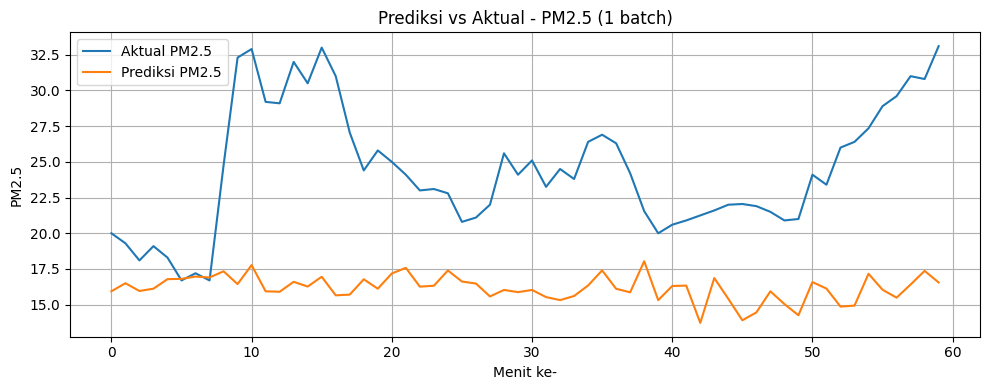

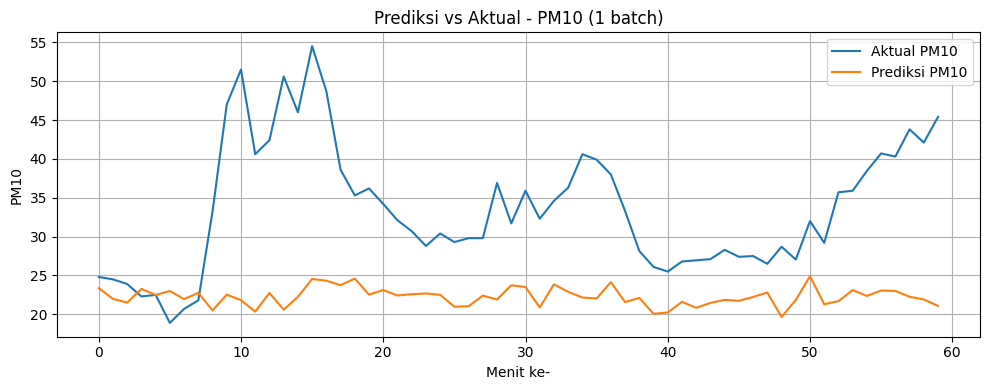

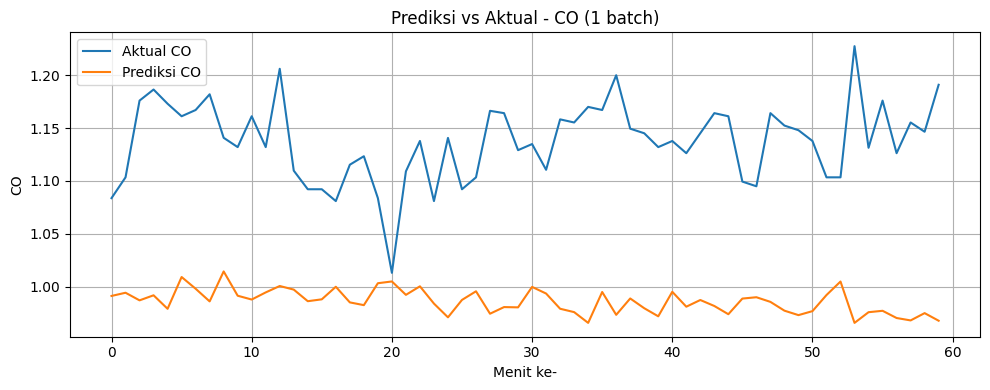

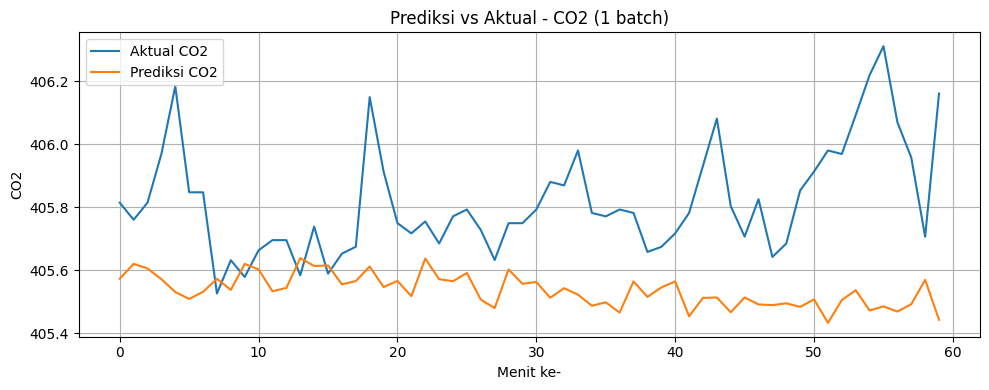

In [89]:
for x_batch, y_true_batch in ahead_test_ds.take(1):
    y_pred_batch = model_6.predict(x_batch)
    y_true_batch = y_true_batch.numpy()

    plot_prediction_from_batch(
        y_true_scaled=y_true_batch,
        y_pred_scaled=y_pred_batch,
        scalers=scalers,
        target_cols=[2, 3, 4, 5],
        feature_names=["PM2.5", "PM10", "CO", "CO2"]
    )

**Test Prediksi hanya untuk PM2.5**

In [ ]:
def split_inputs_and_targets_pm25_multistep(series, ahead=60, target_col=2):
    X = series[:, :-ahead, :]                    # (batch, 120, 6)
    Y = series[:, -ahead:, target_col]           # (batch, 60)
    Y = tf.expand_dims(Y, -1)                    # (batch, 60, 1)
    return X, Y


In [ ]:
seq_length = 120
ahead = 60

pm25_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets_pm25_multistep)

pm25_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=val_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets_pm25_multistep)

pm25_test_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
).map(split_inputs_and_targets_pm25_multistep)

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

pm25_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(120, train_scaled.shape[1])),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(256),
    tf.keras.layers.Dense(60),
    tf.keras.layers.Reshape((60, 1))
])

In [ ]:
pm25_model.compile(
    loss="mse",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["mae"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

with tf.device('/GPU:0'):
    history = pm25_model.fit(
        pm25_train_ds,
        validation_data=pm25_valid_ds,
        epochs=30,
        callbacks=[early_stopping]
    )


Epoch 1/30
89/89 [==============================] - 5s 32ms/step - loss: 0.0201 - mae: 0.1006 - val_loss: 0.0039 - val_mae: 0.0498
Epoch 2/30
89/89 [==============================] - 2s 22ms/step - loss: 0.0109 - mae: 0.0791 - val_loss: 0.0027 - val_mae: 0.0399
Epoch 3/30
89/89 [==============================] - 2s 22ms/step - loss: 0.0101 - mae: 0.0764 - val_loss: 0.0048 - val_mae: 0.0566
Epoch 4/30
89/89 [==============================] - 2s 21ms/step - loss: 0.0102 - mae: 0.0769 - val_loss: 0.0030 - val_mae: 0.0424
Epoch 5/30
89/89 [==============================] - 2s 21ms/step - loss: 0.0093 - mae: 0.0734 - val_loss: 0.0091 - val_mae: 0.0819
Epoch 6/30
89/89 [==============================] - 2s 21ms/step - loss: 0.0094 - mae: 0.0737 - val_loss: 0.0059 - val_mae: 0.0612
Epoch 7/30
89/89 [==============================] - 2s 21ms/step - loss: 0.0100 - mae: 0.0762 - val_loss: 0.0043 - val_mae: 0.0549
Epoch 8/30
89/89 [==============================] - 2s 21ms/step - loss: 0.0094 - m

In [ ]:
pm25_model.evaluate(pm25_test_ds)

15/15 [==============================] - 0s 9ms/step - loss: 0.0112 - mae: 0.0806


[0.011196167208254337, 0.08056917041540146]

1/1 [==============================] - 0s 402ms/step


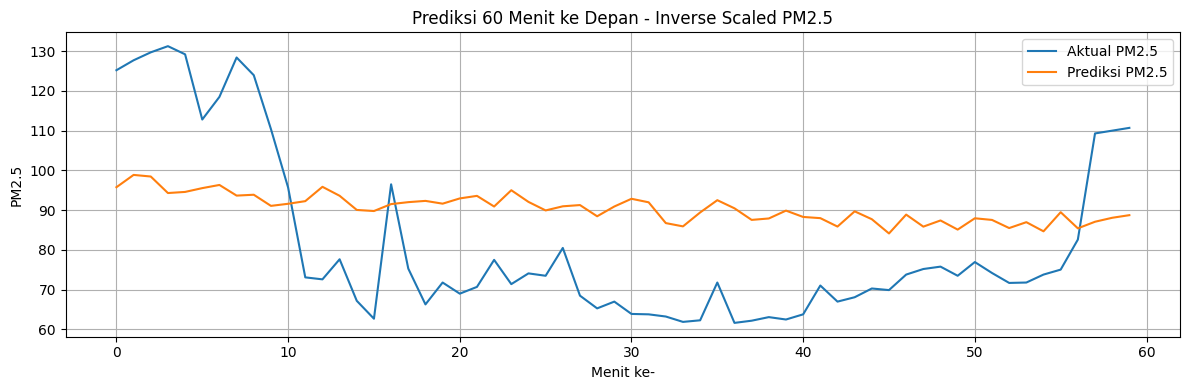

In [ ]:
for x_batch, y_true in pm25_test_ds.take(1):
    y_pred = pm25_model.predict(x_batch)

    # Ambil 1 sample dari batch
    y_true_sample = y_true[0].numpy().reshape(-1, 1)
    y_pred_sample = y_pred[0].reshape(-1, 1)

    # Inverse scaling
    y_true_inv = scalers[2].inverse_transform(y_true_sample).flatten()
    y_pred_inv = scalers[2].inverse_transform(y_pred_sample).flatten()

    # Plot
    plt.figure(figsize=(12, 4))
    plt.plot(y_true_inv, label='Aktual PM2.5')
    plt.plot(y_pred_inv, label='Prediksi PM2.5')
    plt.title('Prediksi 60 Menit ke Depan - Inverse Scaled PM2.5')
    plt.xlabel('Menit ke-')
    plt.ylabel('PM2.5')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
x_batch.shape

TensorShape([32, 120, 6])

In [ ]:
pm25_model.input_shape

(None, 120, 6)

In [ ]:
for x_batch, y_true in pm25_test_ds.take(1):
    print(x_batch.shape)  # Harusnya: (32, 60, 6)
    print(y_true.shape)   # Harusnya: (32, 1, 1)

(32, 120, 6)
(32, 60, 1)


In [ ]:
y_pred = pm25_model.predict(x_batch)


1/1 [==============================] - 0s 31ms/step


**Trial Seq2seq**

In [ ]:
def to_seq2seq_dataset(series, seq_length=60, ahead=60, target_cols=[2, 3, 4, 5],
                       batch_size=32, shuffle=False, seed=None):
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=series,
        targets=None,
        sequence_length=seq_length + ahead,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=batch_size,
        seed=seed
    ).map(lambda S: (
        S[:, :seq_length, :],
        tf.gather(S[:, seq_length:, :], target_cols, axis=-1)
    ))
    return ds

In [ ]:
seq2seq_train = to_seq2seq_dataset(train_scaled, shuffle=True, seed=42)
seq2seq_valid = to_seq2seq_dataset(val_scaled)
seq2seq_test = to_seq2seq_dataset(test_scaled)

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
tf.keras.backend.clear_session()
seq2seq_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=[None, 6]),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(60 * 4),                 # 60 langkah output * 4 fitur
    tf.keras.layers.Reshape((60, 4))               # Kembalikan ke shape: (60, 4)
])

In [ ]:
seq2seq_model.compile(loss="mse", optimizer=optimizer, metrics=["mse"])

In [ ]:
with tf.device('/GPU:0'):
    history = seq2seq_model.fit(seq2seq_train, epochs=30, validation_data=seq2seq_valid, callbacks=[early_stopping_cb, checkpoint_cb])

Epoch 1/30
91/91 [==============================] - 5s 39ms/step - loss: 0.1841 - mse: 0.1841 - val_loss: 0.0311 - val_mse: 0.0311
Epoch 2/30
91/91 [==============================] - 3s 35ms/step - loss: 0.0220 - mse: 0.0220 - val_loss: 0.0219 - val_mse: 0.0219
Epoch 3/30
91/91 [==============================] - 3s 34ms/step - loss: 0.0149 - mse: 0.0149 - val_loss: 0.0232 - val_mse: 0.0232
Epoch 4/30
91/91 [==============================] - 3s 35ms/step - loss: 0.0144 - mse: 0.0144 - val_loss: 0.0258 - val_mse: 0.0258
Epoch 5/30
91/91 [==============================] - 3s 35ms/step - loss: 0.0141 - mse: 0.0141 - val_loss: 0.0224 - val_mse: 0.0224
Epoch 6/30
91/91 [==============================] - 3s 35ms/step - loss: 0.0139 - mse: 0.0139 - val_loss: 0.0234 - val_mse: 0.0234
Epoch 7/30
91/91 [==============================] - 3s 35ms/step - loss: 0.0134 - mse: 0.0134 - val_loss: 0.0196 - val_mse: 0.0196
Epoch 8/30
91/91 [==============================] - 3s 35ms/step - loss: 0.0134 - m

In [ ]:
seq2seq_model.evaluate(seq2seq_test)

17/17 [==============================] - 0s 9ms/step - loss: 0.5352 - mse: 0.5352


[0.5351564288139343, 0.5351563692092896]

1/1 [==============================] - 0s 306ms/step


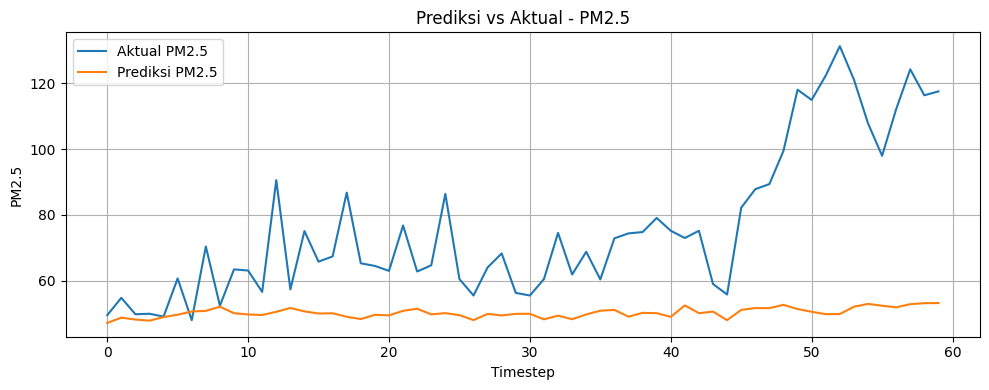

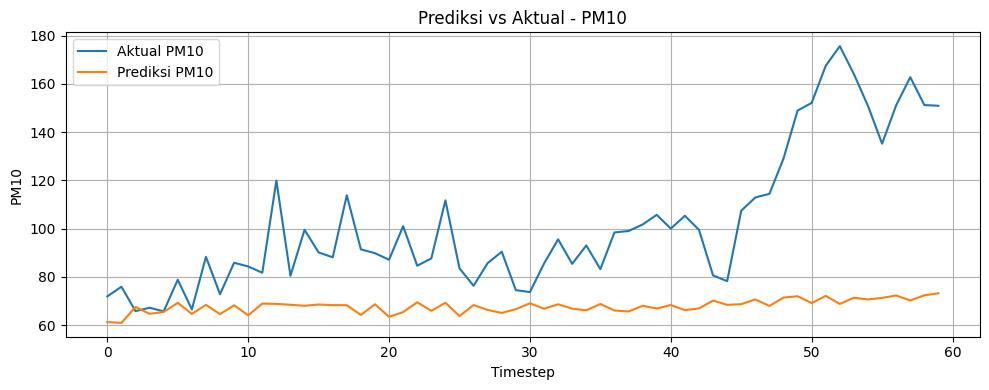

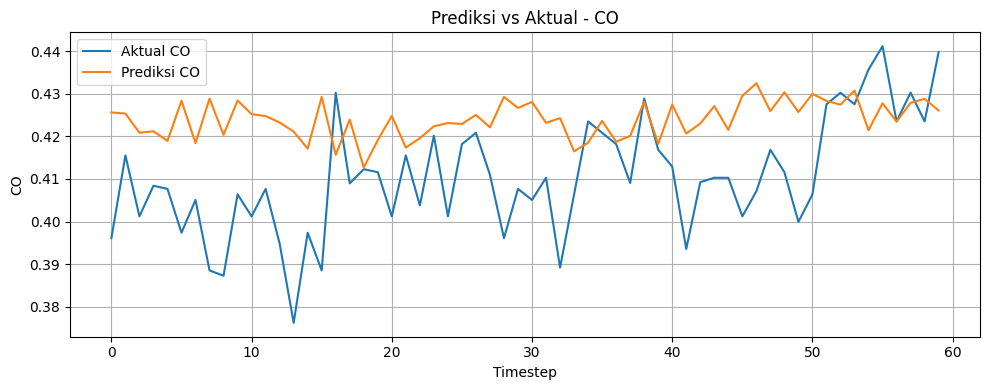

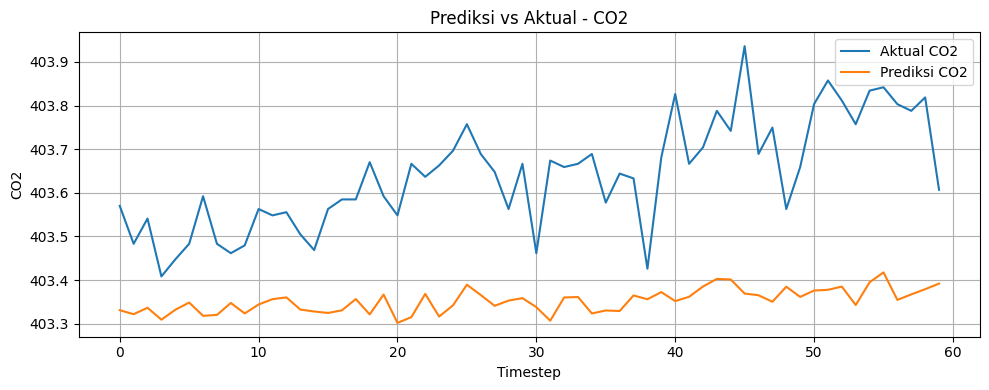

In [ ]:
# Ambil 1 batch dari test set
for X_batch, Y_true in seq2seq_test.take(1):
    Y_pred = seq2seq_model.predict(X_batch)

    # Inverse scaling per fitur
    Y_true_inv = Y_true.numpy().copy()
    Y_pred_inv = Y_pred.copy()

    # target_cols = [2, 3, 4, 5]  # urutan target
    fitur_label = ['PM2.5', 'PM10', 'CO', 'CO2']

    for i, idx in enumerate([2, 3, 4, 5]):
        # Inverse scale untuk fitur target
        scaler = scalers[idx]
        # Bentuk flatten, inverse, lalu reshape ke shape semula
        true_flat = Y_true_inv[:, :, i].reshape(-1, 1)
        pred_flat = Y_pred_inv[:, :, i].reshape(-1, 1)

        true_inv = scaler.inverse_transform(true_flat).reshape(Y_true_inv[:, :, i].shape)
        pred_inv = scaler.inverse_transform(pred_flat).reshape(Y_pred_inv[:, :, i].shape)

        # Visualisasi untuk batch pertama dan fitur ke-i
        plt.figure(figsize=(10, 4))
        plt.plot(true_inv[0], label=f"Aktual {fitur_label[i]}")
        plt.plot(pred_inv[0], label=f"Prediksi {fitur_label[i]}")
        plt.title(f"Prediksi vs Aktual - {fitur_label[i]}")
        plt.xlabel("Timestep")
        plt.ylabel(fitur_label[i])
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


**Dengan Encoder**

In [ ]:
def make_seq2seq_dataset(data, seq_length=60, ahead=60, target_cols=[2,3,4,5],
                         batch_size=32, shuffle=False, seed=None):
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data,
        targets=None,
        sequence_length=seq_length + ahead,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=batch_size,
        seed=seed
    )

    def map_fn(S):
        encoder_in = S[:, :seq_length, :]
        target_seq = tf.gather(S[:, seq_length:, :], target_cols, axis=-1)
        # decoder input = target sequence geser 1 langkah + padding di depan
        dec_in = tf.pad(target_seq[:, :-1, :], [[0,0],[1,0],[0,0]])
        return (encoder_in, dec_in), target_seq

    return ds.map(map_fn)


In [ ]:
seq2seq_train_enc = make_seq2seq_dataset(train_scaled)
seq2seq_valid_enc = make_seq2seq_dataset(val_scaled)
seq2seq_test_enc  = make_seq2seq_dataset(test_scaled)


In [ ]:
tf.keras.backend.clear_session()

# Encoder-decoder model build di sini

# Encoder
encoder_inputs = Input(shape=(60, 6))  # 60 langkah, 6 fitur input
encoder_lstm = LSTM(128, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)

# Decoder
decoder_inputs = Input(shape=(60, 4))  # decoder input (output sebelumnya)
decoder_lstm = LSTM(128, return_sequences=True)
decoder_outputs = decoder_lstm(decoder_inputs, initial_state=[state_h, state_c])
decoder_dense = Dense(4)  # output 4 fitur per step
decoder_outputs = decoder_dense(decoder_outputs)

# Model
seq2seq_model_enc = Model([encoder_inputs, decoder_inputs], decoder_outputs)

In [ ]:
seq2seq_model_enc.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 60, 6)]      0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 60, 4)]      0           []                               
                                                                                                  
 lstm (LSTM)                    [(None, 128),        69120       ['input_1[0][0]']                
                                 (None, 128),                                                     
                                 (None, 128)]                                                     
                                                                                              

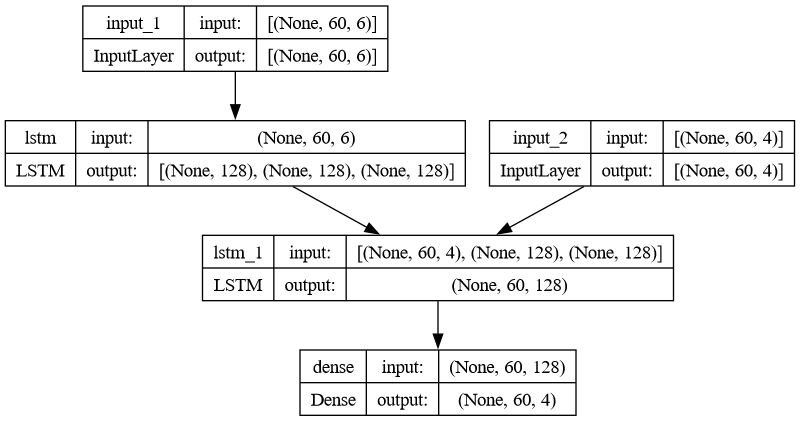

In [ ]:
tf.keras.utils.plot_model(seq2seq_model_enc, show_shapes=True)

In [ ]:
seq2seq_model_enc.compile(optimizer="adam", loss="mse", metrics=["mse"])

In [ ]:
history = seq2seq_model_enc.fit(
    seq2seq_train_enc,
    epochs=30,
    validation_data=seq2seq_valid_enc,
    callbacks=[early_stopping_cb, checkpoint_cb]
)


Epoch 1/30
91/91 [==============================] - 4s 26ms/step - loss: 0.0158 - mse: 0.0158 - val_loss: 0.0133 - val_mse: 0.0133
Epoch 2/30
91/91 [==============================] - 1s 14ms/step - loss: 0.0106 - mse: 0.0106 - val_loss: 0.0110 - val_mse: 0.0110
Epoch 3/30
91/91 [==============================] - 1s 14ms/step - loss: 0.0093 - mse: 0.0093 - val_loss: 0.0086 - val_mse: 0.0086
Epoch 4/30
91/91 [==============================] - 1s 14ms/step - loss: 0.0073 - mse: 0.0073 - val_loss: 0.0069 - val_mse: 0.0069
Epoch 5/30
91/91 [==============================] - 1s 15ms/step - loss: 0.0062 - mse: 0.0062 - val_loss: 0.0054 - val_mse: 0.0054
Epoch 6/30
91/91 [==============================] - 1s 16ms/step - loss: 0.0052 - mse: 0.0052 - val_loss: 0.0048 - val_mse: 0.0048
Epoch 7/30
91/91 [==============================] - 1s 14ms/step - loss: 0.0045 - mse: 0.0045 - val_loss: 0.0048 - val_mse: 0.0048
Epoch 8/30
91/91 [==============================] - 1s 14ms/step - loss: 0.0042 - m

1/1 [==============================] - 0s 440ms/step


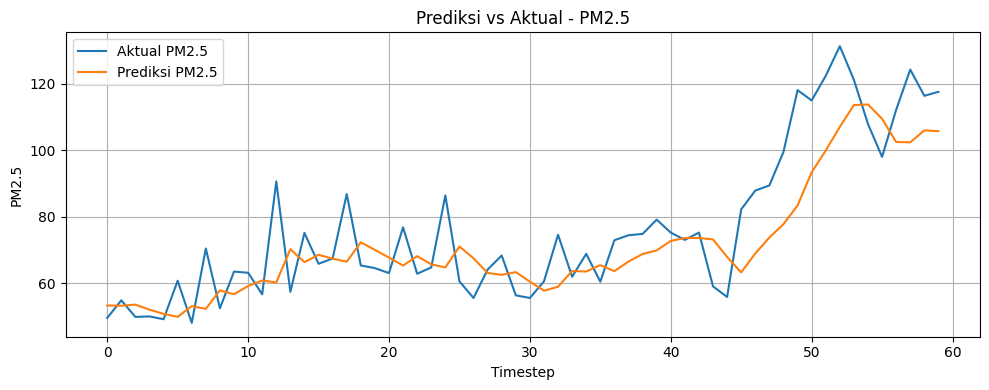

RMSE PM2.5: 12.583


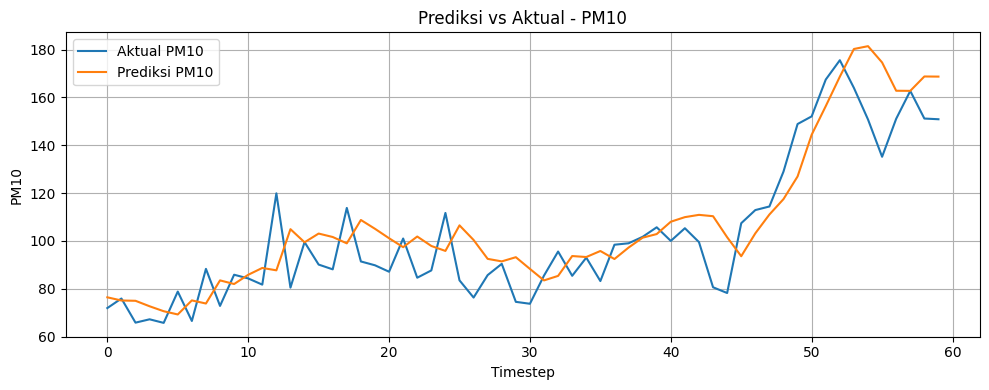

RMSE PM10: 14.568


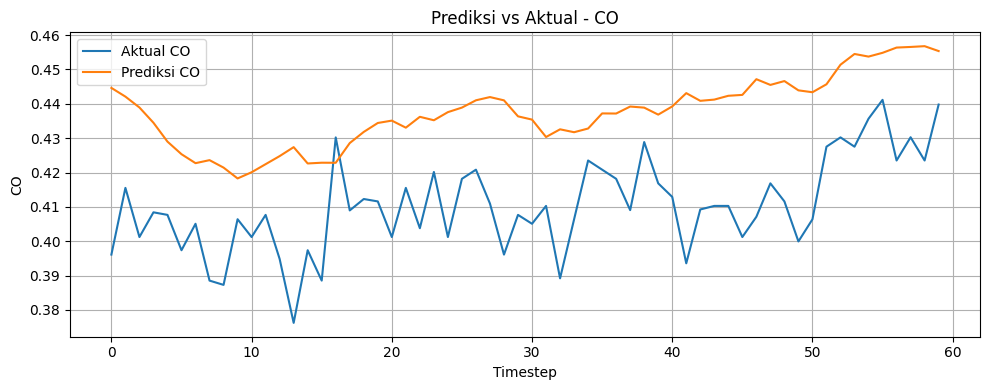

RMSE CO: 0.029


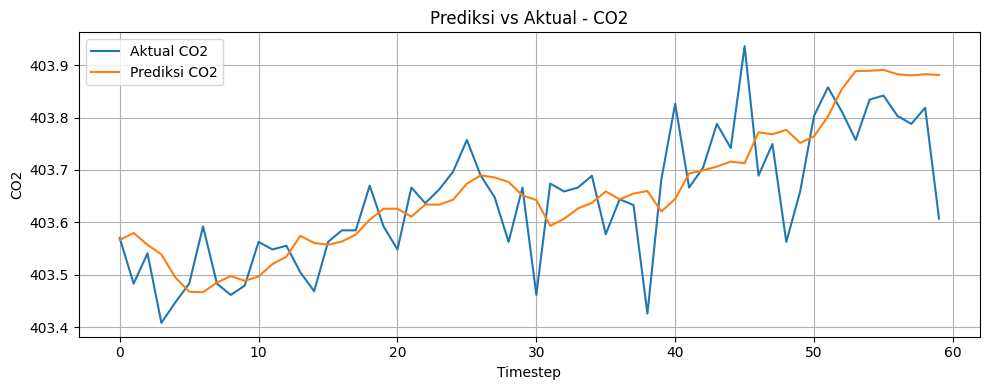

RMSE CO2: 0.091


In [ ]:
from sklearn.metrics import mean_squared_error

for (encoder_in, decoder_in), Y_true in seq2seq_test_enc.take(1):
    Y_pred = seq2seq_model_enc.predict([encoder_in, decoder_in])

    fitur_label = ['PM2.5', 'PM10', 'CO', 'CO2']
    for i, idx in enumerate([2, 3, 4, 5]):
        scaler = scalers[idx]

        true_flat = Y_true[:, :, i].numpy().reshape(-1, 1)
        pred_flat = Y_pred[:, :, i].reshape(-1, 1)

        true_inv = scaler.inverse_transform(true_flat).reshape(Y_true[:, :, i].shape)
        pred_inv = scaler.inverse_transform(pred_flat).reshape(Y_pred[:, :, i].shape)

        # Plot
        plt.figure(figsize=(10,4))
        plt.plot(true_inv[0], label=f"Aktual {fitur_label[i]}")
        plt.plot(pred_inv[0], label=f"Prediksi {fitur_label[i]}")
        plt.title(f"Prediksi vs Aktual - {fitur_label[i]}")
        plt.xlabel("Timestep")
        plt.ylabel(fitur_label[i])
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # RMSE
        rmse = np.sqrt(mean_squared_error(true_inv[0], pred_inv[0]))
        print(f"RMSE {fitur_label[i]}: {rmse:.3f}")
